# Лабораторная работа №3. ОБУЧЕНИЕ С УЧИТЕЛЕМ. ЗАДАЧА КЛАССИФИКАЦИИ
## Классификация мошеннических транзакций

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import uniform
import warnings
warnings.filterwarnings('ignore')


import time
import optuna
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, roc_auc_score, roc_curve,
                             precision_recall_curve, average_precision_score)

# Импорт собственных модулей
from my_metrics import (calc_accuracy, calc_precision, calc_recall, calc_f1, calc_confusion_matrix, print_metrics)
from my_knn import MyKNN

print('Все модули загружены успешно.')

# Настройки визуализации
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

Все модули загружены успешно.


## 1. Загрузка и первичный анализ данных

In [4]:
df = pd.read_csv('new_data_card.csv')

print(f"Датасет: {df.shape[0]} строк, {df.shape[1]} столбцов")
print(f"\n{'='*50}")
print("Информация о данных:")
print(f"{'='*50}")
df.info()
print(f"\n{'='*50}")
print("Первые 10 строк:")
print(f"{'='*50}")
display(df.head(10))

Датасет: 1000000 строк, 9 столбцов

Информация о данных:
<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 9 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Unnamed: 0                      1000000 non-null  int64  
 1   distance_from_home              1000000 non-null  float64
 2   distance_from_last_transaction  1000000 non-null  float64
 3   ratio_to_median_purchase_price  1000000 non-null  float64
 4   repeat_retailer                 1000000 non-null  bool   
 5   used_chip                       1000000 non-null  bool   
 6   used_pin_number                 1000000 non-null  bool   
 7   online_order                    1000000 non-null  bool   
 8   fraud                           1000000 non-null  bool   
dtypes: bool(5), float64(3), int64(1)
memory usage: 35.3 MB

Первые 10 строк:


,Unnamed: 0,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,0,57.877857,0.311140,1.945940,True,True,False,False,False
1,1,10.829943,0.175592,1.294219,True,False,False,False,False
2,2,5.091079,0.805153,0.427715,True,False,False,True,False
3,3,2.247564,5.600044,0.362663,True,True,False,True,False
4,4,44.190936,0.566486,2.222767,True,True,False,True,False
5,5,5.586408,13.261073,0.064768,True,False,False,False,False
6,6,3.724019,0.956838,0.278465,True,False,False,True,False
7,7,4.848247,0.320735,1.273050,True,False,True,False,False
8,8,0.876632,2.503609,1.516999,False,False,False,False,False
9,9,8.839047,2.970512,2.361683,True,False,False,True,False


## 2. Подготовка данных

In [5]:
# Выделяем целевой признак и предикторы
X = df.drop(columns=['fraud', 'Unnamed: 0'])
y = df['fraud']

print(f"Целевой признак: fraud (бинарный — True/False)")
print(f"Предикторы ({X.shape[1]} шт.): {list(X.columns)}")
print(f"\nЗадача: бинарная классификация")
print(f"Общий баланс классов:\n{y.value_counts(normalize=True).to_string()}")

Целевой признак: fraud (бинарный — True/False)
Предикторы (7 шт.): ['distance_from_home', 'distance_from_last_transaction', 'ratio_to_median_purchase_price', 'repeat_retailer', 'used_chip', 'used_pin_number', 'online_order']

Задача: бинарная классификация
Общий баланс классов:
fraud
False    0.912597
True     0.087403


In [6]:
# ============================================================
# HOLD-OUT: train / val / test = 60% / 20% / 20% (стратифицированный)
# ============================================================

# Первый сплит: 60% train, 40% (val + test)
X_train, X_valtest, y_train, y_valtest = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)

# Второй сплит: из 40% — пополам val и test (20% / 20%)
X_val, X_test, y_val, y_test = train_test_split(
    X_valtest, y_valtest, test_size=0.5, random_state=42
)

print("HOLD-OUT разделение (стратифицированное):")
print(f"  Train: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%), fraud: {y_train.sum()}")
print(f"  Val:   {len(X_val)} ({len(X_val)/len(X)*100:.1f}%), fraud: {y_val.sum()}")
print(f"  Test:  {len(X_test)} ({len(X_test)/len(X)*100:.1f}%), fraud: {y_test.sum()}")
print(f"\nДоля fraud в train: {y_train.mean()*100:.2f}%")
print(f"Доля fraud в val:   {y_val.mean()*100:.2f}%")
print(f"Доля fraud в test:  {y_test.mean()*100:.2f}%")

HOLD-OUT разделение (стратифицированное):
  Train: 600000 (60.0%), fraud: 52442
  Val:   200000 (20.0%), fraud: 17357
  Test:  200000 (20.0%), fraud: 17604

Доля fraud в train: 8.74%
Доля fraud в val:   8.68%
Доля fraud в test:  8.80%


In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Масштабирование выполнено (StandardScaler).")
print(f"Train: mean={X_train_scaled.mean():.4f}, std={X_train_scaled.std():.4f}")

Масштабирование выполнено (StandardScaler).
Train: mean=0.0000, std=1.0000


In [8]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
print(f"Настроена кросс-валидация: StratifiedKFold(n_splits=10)")

Настроена кросс-валидация: StratifiedKFold(n_splits=10)


In [9]:
def print_classification_report(y_true, y_pred, model_name, target_names=None):
    if target_names is None:
        target_names = [str(c) for c in sorted(pd.Series(y_true).unique())]
        
    print(f"\n Classification Report: {model_name}")
    print("=" * 45)
    print(classification_report(y_true, y_pred, target_names=target_names))
    report_dict = classification_report(y_true, y_pred, target_names=target_names, output_dict=True)
    df_report = pd.DataFrame(report_dict).T
    return df_report.style.format('{:.3f}')

In [10]:
smote = SMOTE(random_state=42, sampling_strategy='auto')

X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)
y_train_bal = pd.Series(y_train_bal, name=y_train.name)

In [11]:
print("РАСПРЕДЕЛЕНИЕ ПОСЛЕ БАЛАНСИРОВКИ:")
print(f"  Train (bal): {len(X_train_bal)} | fraud: {y_train_bal.sum()} ({y_train_bal.mean()*100:.1f}%)")
print(f"  Val:         {len(X_val)} | fraud: {y_val.sum()} ({y_val.mean()*100:.1f}%)")
print(f"  Test:        {len(X_test)} | fraud: {y_test.sum()} ({y_test.mean()*100:.1f}%)")

assert abs(len(X_val)/len(X) - 0.2) < 0.01, "Ошибка валидационной доли"
assert abs(len(X_test)/len(X) - 0.2) < 0.01, "Ошибка тестовой доли"

РАСПРЕДЕЛЕНИЕ ПОСЛЕ БАЛАНСИРОВКИ:
  Train (bal): 1095116 | fraud: 547558 (50.0%)
  Val:         200000 | fraud: 17357 (8.7%)
  Test:        200000 | fraud: 17604 (8.8%)


## 4. Решение задачи классификации

### 4.1 Logistic Regression

In [12]:
print("="*70)
print("ПОДБОР ГИПЕРПАРАМЕТРОВ ТРЕМЯ СПОСОБАМИ")
print("="*70)

np.random.seed(42)
lr_search_idx = np.random.choice(len(X_train_bal), size=500000, replace=False)
X_lr_search = X_train_bal[lr_search_idx]
y_lr_search = y_train_bal.iloc[lr_search_idx]

print(f"Размер выборки для поиска: {len(X_lr_search)}\n")

param_dist_lr = {
    'C': uniform(0.01, 100),
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],
    'max_iter': [500, 1000, 2000]
}

param_grid_lr = {
    'C': [0.1, 1, 10, 50, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],
    'max_iter': [1000, 2000]
}

best_params = {}

# 1. RandomizedSearchCV
print("\n" + "="*70)
print("1. RandomizedSearchCV")
print("="*70)
start_time = time.time()

random_search_lr = RandomizedSearchCV(
    LogisticRegression(class_weight='balanced', random_state=42),
    param_distributions=param_dist_lr,
    n_iter=20,
    scoring='f1',
    cv=3,
    random_state=42,
    n_jobs=-1
)
random_search_lr.fit(X_lr_search, y_lr_search)

best_params['random'] = random_search_lr.best_params_
print(f"Лучшие параметры: {best_params['random']}")
print(f"F1 (CV): {random_search_lr.best_score_:.4f}")
print(f"Время: {(time.time() - start_time)/60:.2f} мин.")

# 2. GridSearchCV
print("\n" + "="*70)
print("2. GridSearchCV")
print("="*70)
start_time = time.time()

grid_search_lr = GridSearchCV(
    LogisticRegression(class_weight='balanced', random_state=42),
    param_grid=param_grid_lr,
    scoring='f1',
    cv=3,
    n_jobs=-1
)
grid_search_lr.fit(X_lr_search, y_lr_search)

best_params['grid'] = grid_search_lr.best_params_
print(f"Лучшие параметры: {best_params['grid']}")
print(f"F1 (CV): {grid_search_lr.best_score_:.4f}")
print(f"Время: {(time.time() - start_time)/60:.2f} мин.")

# 3. Optuna
print("\n" + "="*70)
print("3. Optuna")
print("="*70)

def objective(trial):
    C = trial.suggest_float('C', 0.01, 100, log=True)
    penalty = trial.suggest_categorical('penalty', ['l1', 'l2'])
    max_iter = trial.suggest_categorical('max_iter', [500, 1000, 2000])
    
    model = LogisticRegression(
        C=C, penalty=penalty, solver='liblinear',
        class_weight='balanced', max_iter=max_iter, random_state=42
    )
    scores = cross_val_score(model, X_lr_search, y_lr_search, cv=3, scoring='f1', n_jobs=-1)
    return scores.mean()

start_time = time.time()
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30, show_progress_bar=True)

best_params['optuna'] = study.best_params
print(f"\nЛучшие параметры: {best_params['optuna']}")
print(f"F1 (CV): {study.best_value:.4f}")
print(f"Время: {(time.time() - start_time)/60:.2f} мин.")

print(f"\nbest_params['random']: {best_params['random']}")
print(f"best_params['grid']:   {best_params['grid']}")
print(f"best_params['optuna']: {best_params['optuna']}")
print("="*70)

ПОДБОР ГИПЕРПАРАМЕТРОВ ТРЕМЯ СПОСОБАМИ
Размер выборки для поиска: 500000


1. RandomizedSearchCV
Лучшие параметры: {'C': np.float64(3.4488521115218393), 'max_iter': 1000, 'penalty': 'l1', 'solver': 'liblinear'}
F1 (CV): 0.9416
Время: 0.30 мин.

2. GridSearchCV


[I 2026-05-10 20:35:05,836] A new study created in memory with name: no-name-de4156cd-f734-4463-8b50-80ed6377d14c


Лучшие параметры: {'C': 1, 'max_iter': 1000, 'penalty': 'l1', 'solver': 'liblinear'}
F1 (CV): 0.9416
Время: 0.24 мин.

3. Optuna


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-05-10 20:35:06,917] Trial 0 finished with value: 0.9415995802640772 and parameters: {'C': 86.63047948660885, 'penalty': 'l2', 'max_iter': 2000}. Best is trial 0 with value: 0.9415995802640772.
[I 2026-05-10 20:35:07,809] Trial 1 finished with value: 0.9416208244337078 and parameters: {'C': 7.842858664501973, 'penalty': 'l1', 'max_iter': 500}. Best is trial 1 with value: 0.9416208244337078.
[I 2026-05-10 20:35:08,724] Trial 2 finished with value: 0.9416208244337078 and parameters: {'C': 13.07927511957184, 'penalty': 'l1', 'max_iter': 1000}. Best is trial 1 with value: 0.9416208244337078.
[I 2026-05-10 20:35:09,884] Trial 3 finished with value: 0.9416107434243197 and parameters: {'C': 0.12284199351468499, 'penalty': 'l2', 'max_iter': 2000}. Best is trial 1 with value: 0.9416208244337078.
[I 2026-05-10 20:35:10,743] Trial 4 finished with value: 0.94162292500309 and parameters: {'C': 2.987252991451169, 'penalty': 'l1', 'max_iter': 1000}. Best is trial 4 with value: 0.94162292500309

In [13]:
params = best_params['optuna']

print(f"\nИспользуемые параметры:")
print(f"  C: {params['C']}")
print(f"  penalty: {params['penalty']}")
print(f"  max_iter: {params['max_iter']}")

print(f"\nОбучение на полном датасете ({len(X_train_bal)} объектов)...")
lr_final = LogisticRegression(
    C=params['C'],
    penalty=params['penalty'],
    solver='liblinear',
    class_weight='balanced',
    max_iter=params['max_iter'],
    random_state=42
)
lr_final.fit(X_train_bal, y_train_bal)

print("✓ Модель lr_final обучена!")


Используемые параметры:
  C: 0.010929621503895162
  penalty: l2
  max_iter: 500

Обучение на полном датасете (1095116 объектов)...
✓ Модель lr_final обучена!


In [14]:
# Оценка Logistic Regression на test
y_pred_lr = lr_final.predict(X_test_scaled)
y_proba_lr = lr_final.predict_proba(X_test_scaled)[:, 1]

print("\n" + "="*50)
print("LOGISTIC REGRESSION — результаты на тестовой выборке")
print("="*50)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_lr):.4f}")
print(f"ROC AUC:   {roc_auc_score(y_test, y_proba_lr):.4f}")
print(f"\nМатрица ошибок:")
print(confusion_matrix(y_test, y_pred_lr))
print(f"\nОтчёт по классификации:")
print(classification_report(y_test, y_pred_lr, target_names=['Не мошенничество', 'Мошенничество']))


LOGISTIC REGRESSION — результаты на тестовой выборке
Accuracy:  0.9343
Precision: 0.5770
Recall:    0.9508
F1-score:  0.7182
ROC AUC:   0.9798

Матрица ошибок:
[[170124  12272]
 [   866  16738]]

Отчёт по классификации:
                  precision    recall  f1-score   support

Не мошенничество       0.99      0.93      0.96    182396
   Мошенничество       0.58      0.95      0.72     17604

        accuracy                           0.93    200000
       macro avg       0.79      0.94      0.84    200000
    weighted avg       0.96      0.93      0.94    200000



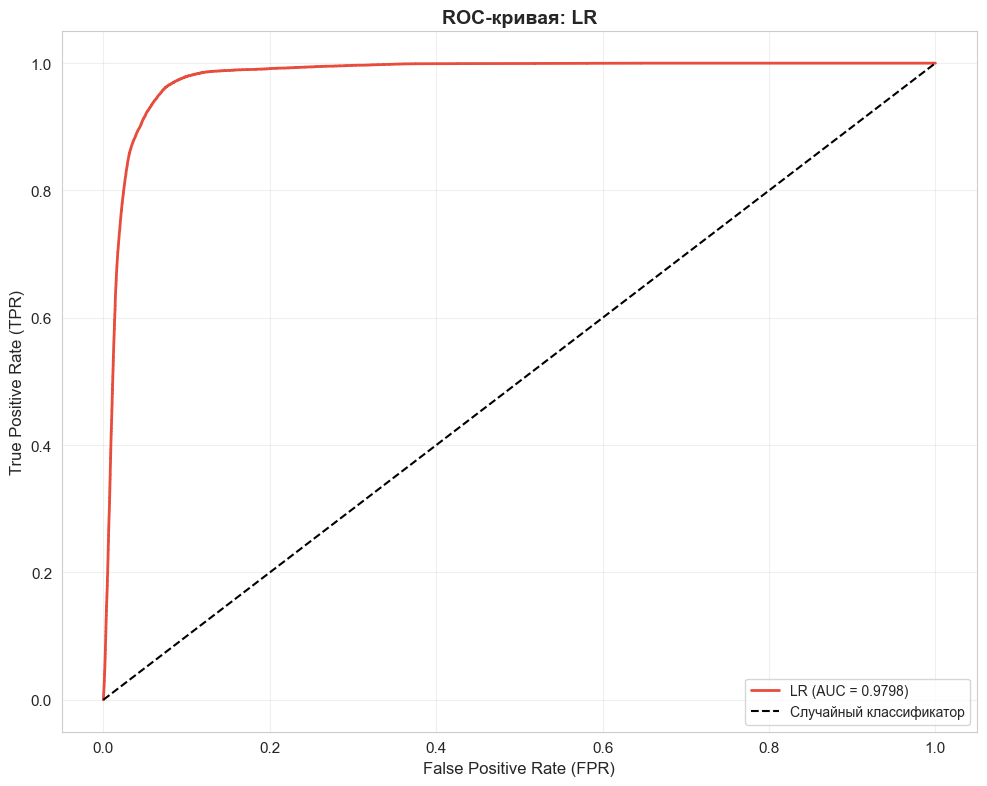

AUC для LR: 0.9798
--------------------------------------------------


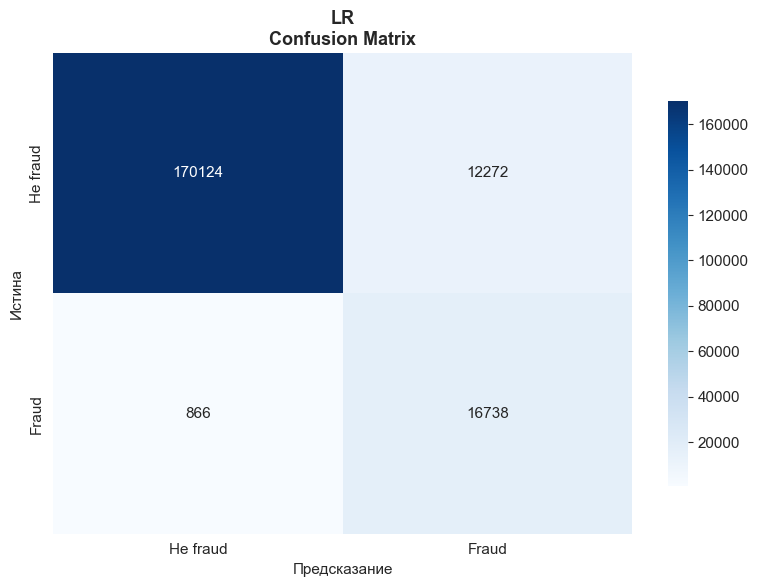


Classification Report для LR:
              precision    recall  f1-score   support

    Не fraud       0.99      0.93      0.96    182396
       Fraud       0.58      0.95      0.72     17604

    accuracy                           0.93    200000
   macro avg       0.79      0.94      0.84    200000
weighted avg       0.96      0.93      0.94    200000



In [15]:
model = lr_final      #  обученная модель
model_name = 'LR'     #  название для графиков

try:
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
except AttributeError:
    from sklearn.preprocessing import MinMaxScaler
    y_proba = model.decision_function(X_test_scaled)
    y_proba = MinMaxScaler().fit_transform(y_proba.reshape(-1, 1)).ravel()

y_pred = model.predict(X_test_scaled)

# ГРАФИК 1: ROC Curve
plt.figure(figsize=(10, 8))
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.plot(fpr, tpr, color='#e74c3c', lw=2, label=f'{model_name} (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Случайный классификатор')

plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title(f'ROC-кривая: {model_name}', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'AUC для {model_name}: {auc:.4f}')
print('-' * 50)

# ГРАФИК 2: Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Не fraud', 'Fraud'],
            yticklabels=['Не fraud', 'Fraud'],
            cbar_kws={'shrink': 0.8})

ax.set_title(f'{model_name}\nConfusion Matrix', fontsize=13, fontweight='bold')
ax.set_xlabel('Предсказание', fontsize=11)
ax.set_ylabel('Истина', fontsize=11)
plt.tight_layout()
plt.show()

# Дополнительные метрики
from sklearn.metrics import classification_report
print(f"\nClassification Report для {model_name}:")
print(classification_report(y_test, y_pred, target_names=['Не fraud', 'Fraud']))

### 4.2.1 kNN (scikit-learn)

In [16]:
import numpy as np
import time
import optuna
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, cross_val_score

print("="*70)
print("ПОДБОР ГИПЕРПАРАМЕТРОВ kNN ТРЕМЯ СПОСОБАМИ")
print("="*70)

np.random.seed(42)
knn_search_idx = np.random.choice(len(X_train_bal), size=500000, replace=False)
X_knn_search = X_train_bal[knn_search_idx]
y_knn_search = y_train_bal.iloc[knn_search_idx]

print(f"Размер выборки для поиска: {len(X_knn_search)}\n")

param_dist_knn = {
    'n_neighbors': range(3, 31, 2),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'p': [1, 2]
}

param_grid_knn = {
    'n_neighbors': [5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan'],
    'p': [1, 2]
}

best_params = {}

# 1. RandomizedSearchCV
print("\n" + "="*70)
print("1. RandomizedSearchCV")
print("="*70)
start_time = time.time()

random_search_knn = RandomizedSearchCV(
    KNeighborsClassifier(),
    param_distributions=param_dist_knn,
    n_iter=15,
    scoring='f1',
    cv=3,
    random_state=42,
    n_jobs=-1
)
random_search_knn.fit(X_knn_search, y_knn_search)

best_params['random'] = random_search_knn.best_params_
print(f"Лучшие параметры: {best_params['random']}")
print(f"F1 (CV): {random_search_knn.best_score_:.4f}")
print(f"Время: {(time.time() - start_time)/60:.2f} мин.")

# 2. GridSearchCV
print("\n" + "="*70)
print("2. GridSearchCV")
print("="*70)
start_time = time.time()

grid_search_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid=param_grid_knn,
    scoring='f1',
    cv=3,
    n_jobs=-1
)
grid_search_knn.fit(X_knn_search, y_knn_search)

best_params['grid'] = grid_search_knn.best_params_
print(f"Лучшие параметры: {best_params['grid']}")
print(f"F1 (CV): {grid_search_knn.best_score_:.4f}")
print(f"Время: {(time.time() - start_time)/60:.2f} мин.")

# 3. Optuna
print("\n" + "="*70)
print("3. Optuna")
print("="*70)

def objective(trial):
    n_neighbors = trial.suggest_int('n_neighbors', 3, 31, step=2)
    weights = trial.suggest_categorical('weights', ['uniform', 'distance'])
    metric = trial.suggest_categorical('metric', ['euclidean', 'manhattan', 'minkowski'])
    p = trial.suggest_int('p', 1, 2)
    
    model = KNeighborsClassifier(
        n_neighbors=n_neighbors,
        weights=weights,
        metric=metric,
        p=p
    )
    scores = cross_val_score(model, X_knn_search, y_knn_search, cv=3, scoring='f1', n_jobs=-1)
    return scores.mean()

start_time = time.time()
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30, show_progress_bar=True)

best_params['optuna'] = study.best_params
print(f"\nЛучшие параметры: {best_params['optuna']}")
print(f"F1 (CV): {study.best_value:.4f}")
print(f"Время: {(time.time() - start_time)/60:.2f} мин.")

print(f"\nbest_params_knn['random']: {best_params['random']}")
print(f"best_params_knn['grid']:   {best_params['grid']}")
print(f"best_params_knn['optuna']: {best_params['optuna']}")
print("="*70)

ПОДБОР ГИПЕРПАРАМЕТРОВ kNN ТРЕМЯ СПОСОБАМИ
Размер выборки для поиска: 500000


1. RandomizedSearchCV
Лучшие параметры: {'weights': 'distance', 'p': 2, 'n_neighbors': 5, 'metric': 'minkowski'}
F1 (CV): 0.9984
Время: 2.68 мин.

2. GridSearchCV


[I 2026-05-10 20:44:06,974] A new study created in memory with name: no-name-07b13d3d-1b03-4c7d-9522-162af3028dea


Лучшие параметры: {'metric': 'euclidean', 'n_neighbors': 5, 'p': 1, 'weights': 'distance'}
F1 (CV): 0.9984
Время: 5.81 мин.

3. Optuna


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-05-10 20:44:29,912] Trial 0 finished with value: 0.9962243522612342 and parameters: {'n_neighbors': 31, 'weights': 'uniform', 'metric': 'euclidean', 'p': 1}. Best is trial 0 with value: 0.9962243522612342.
[I 2026-05-10 20:44:48,592] Trial 1 finished with value: 0.9976698405054846 and parameters: {'n_neighbors': 15, 'weights': 'distance', 'metric': 'minkowski', 'p': 2}. Best is trial 1 with value: 0.9976698405054846.
[I 2026-05-10 20:45:11,832] Trial 2 finished with value: 0.9972078765620113 and parameters: {'n_neighbors': 25, 'weights': 'distance', 'metric': 'minkowski', 'p': 1}. Best is trial 1 with value: 0.9976698405054846.
[I 2026-05-10 20:45:35,879] Trial 3 finished with value: 0.9964850621759553 and parameters: {'n_neighbors': 27, 'weights': 'uniform', 'metric': 'manhattan', 'p': 1}. Best is trial 1 with value: 0.9976698405054846.
[I 2026-05-10 20:45:56,544] Trial 4 finished with value: 0.9965386185177683 and parameters: {'n_neighbors': 25, 'weights': 'uniform', 'metric'

In [17]:
from sklearn.neighbors import KNeighborsClassifier

print("="*70)
print("ОБУЧЕНИЕ ФИНАЛЬНОЙ МОДЕЛИ kNN (параметры от Optuna)")
print("="*70)

params = best_params['optuna']

print(f"\nИспользуемые параметры:")
for key, value in params.items():
    print(f"  {key}: {value}")

np.random.seed(42)
knn_train_idx = np.random.choice(len(X_train_bal), size=500000, replace=False)
X_knn_train = X_train_bal[knn_train_idx]
y_knn_train = y_train_bal.iloc[knn_train_idx]

print(f"\nОбучение на подвыборке ({len(X_knn_train)} объектов)...")
knn_final = KNeighborsClassifier(
    n_neighbors=params['n_neighbors'],
    weights=params['weights'],
    metric=params['metric'],
    p=params.get('p', 2)
)
knn_final.fit(X_knn_train, y_knn_train)

print("✓ Модель knn_final обучена!")
print("="*70)

ОБУЧЕНИЕ ФИНАЛЬНОЙ МОДЕЛИ kNN (параметры от Optuna)

Используемые параметры:
  n_neighbors: 3
  weights: distance
  metric: euclidean
  p: 1

Обучение на подвыборке (500000 объектов)...
✓ Модель knn_final обучена!


In [18]:
# Оценка kNN на test
y_pred_knn = knn_final.predict(X_test_scaled)
y_proba_knn = knn_final.predict_proba(X_test_scaled)[:, 1]

print("\n" + "="*50)
print("KNN (sklearn) — результаты на тестовой выборке")
print("="*50)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_knn):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_knn):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_knn):.4f}")
print(f"ROC AUC:   {roc_auc_score(y_test, y_proba_knn):.4f}")
print(f"\nМатрица ошибок:")
print(confusion_matrix(y_test, y_pred_knn))
print(f"\nОтчёт по классификации:")
print(classification_report(y_test, y_pred_knn, target_names=['Не мошенничество', 'Мошенничество']))


KNN (sklearn) — результаты на тестовой выборке
Accuracy:  0.9979
Precision: 0.9787
Recall:    0.9975
F1-score:  0.9880
ROC AUC:   0.9992

Матрица ошибок:
[[182014    382]
 [    44  17560]]

Отчёт по классификации:
                  precision    recall  f1-score   support

Не мошенничество       1.00      1.00      1.00    182396
   Мошенничество       0.98      1.00      0.99     17604

        accuracy                           1.00    200000
       macro avg       0.99      1.00      0.99    200000
    weighted avg       1.00      1.00      1.00    200000



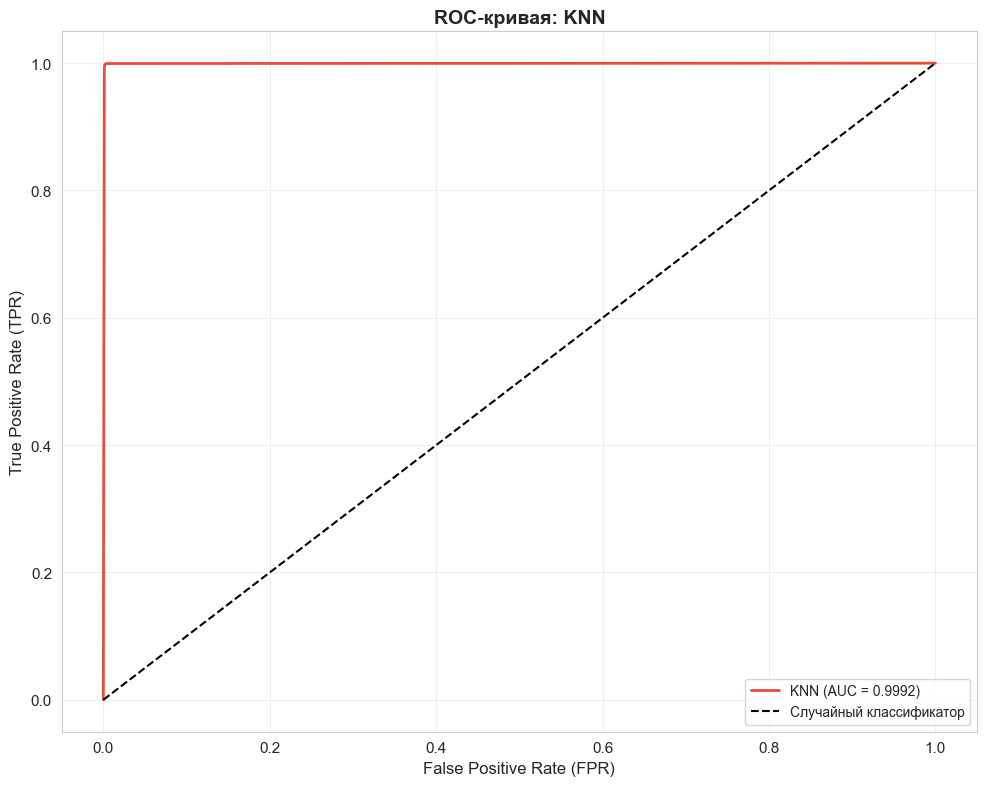

AUC для KNN: 0.9992
--------------------------------------------------


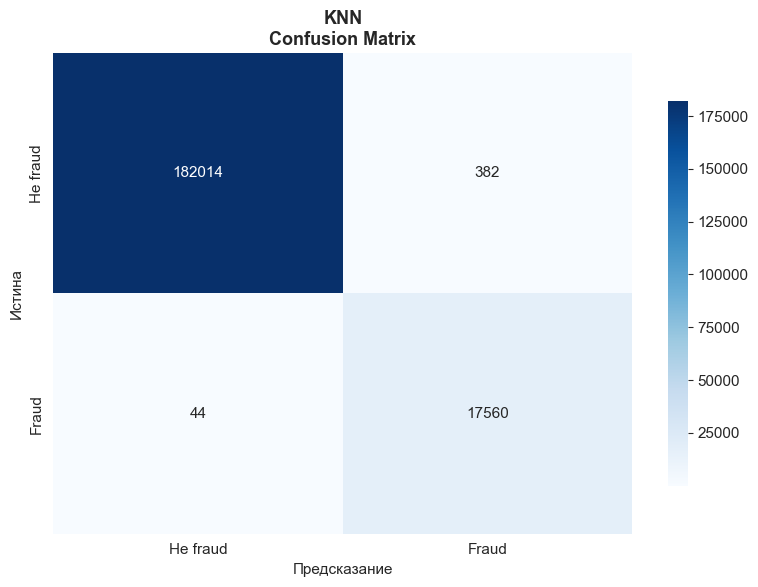


Classification Report для KNN:
              precision    recall  f1-score   support

    Не fraud       1.00      1.00      1.00    182396
       Fraud       0.98      1.00      0.99     17604

    accuracy                           1.00    200000
   macro avg       0.99      1.00      0.99    200000
weighted avg       1.00      1.00      1.00    200000



In [19]:
model = knn_final      #  обученная модель
model_name = 'KNN'     #  название для графиков

try:
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
except AttributeError:
    from sklearn.preprocessing import MinMaxScaler
    y_proba = model.decision_function(X_test_scaled)
    y_proba = MinMaxScaler().fit_transform(y_proba.reshape(-1, 1)).ravel()

y_pred = model.predict(X_test_scaled)

# ГРАФИК 1: ROC Curve
plt.figure(figsize=(10, 8))
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.plot(fpr, tpr, color='#e74c3c', lw=2, label=f'{model_name} (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Случайный классификатор')

plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title(f'ROC-кривая: {model_name}', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'AUC для {model_name}: {auc:.4f}')
print('-' * 50)

# ГРАФИК 2: Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Не fraud', 'Fraud'],
            yticklabels=['Не fraud', 'Fraud'],
            cbar_kws={'shrink': 0.8})

ax.set_title(f'{model_name}\nConfusion Matrix', fontsize=13, fontweight='bold')
ax.set_xlabel('Предсказание', fontsize=11)
ax.set_ylabel('Истина', fontsize=11)
plt.tight_layout()
plt.show()

# Дополнительные метрики
from sklearn.metrics import classification_report
print(f"\nClassification Report для {model_name}:")
print(classification_report(y_test, y_pred, target_names=['Не fraud', 'Fraud']))

### 4.2.2 kNN (Мой)

In [20]:
# Обучаем свой kNN на небольшом сабсемпле (иначе слишком долго)
myknn_sample_size = 500000
myknn_idx = np.random.choice(len(X_train_bal), size=myknn_sample_size, replace=False)

print(f"Обучение MyKNN на {myknn_sample_size} объектах...")

myknn = MyKNN(n_neighbors=5, metric='euclidean', weights='uniform')
myknn.fit(X_train_bal[myknn_idx], y_train_bal.iloc[myknn_idx])
print("MyKNN обучен.")

# Предсказание на небольшом тесте
myknn_test_size = 1000
myknn_test_idx = np.random.choice(len(X_test_scaled), size=myknn_test_size, replace=False)

print(f"\nПредсказание на {myknn_test_size} объектах тестовой выборки...")
y_pred_myknn = myknn.predict(X_test_scaled[myknn_test_idx])
y_true_myknn = y_test.iloc[myknn_test_idx]
print("Предсказание завершено.")

Обучение MyKNN на 500000 объектах...
MyKNN обучен.

Предсказание на 1000 объектах тестовой выборки...
Предсказание завершено.


In [21]:
# Сравниваем свой kNN с sklearn kNN на тех же данных
sklearn_knn_test = KNeighborsClassifier(n_neighbors=5, weights='uniform', metric='euclidean')
sklearn_knn_test.fit(X_train_bal[myknn_idx], y_train_bal.iloc[myknn_idx])
y_pred_sk_knn = sklearn_knn_test.predict(X_test_scaled[myknn_test_idx])

print("\n" + "="*60)
print("СРАВНЕНИЕ: MyKNN vs KNeighborsClassifier (sklearn)")
print("="*60)
print(f"{'Метрика':<15} | {'MyKNN':<12} | {'sklearn kNN':<12} | {'Совпадение'}")
print(f"{'-'*60}")

for metric_name, func in [('Accuracy', accuracy_score), ('Precision', precision_score),
                            ('Recall', recall_score), ('F1', f1_score)]:
    v1 = func(y_true_myknn, y_pred_myknn)
    v2 = func(y_true_myknn, y_pred_sk_knn)
    match = '✓' if abs(v1 - v2) < 0.01 else '~'
    print(f"{metric_name:<15} | {v1:<12.4f} | {v2:<12.4f} | {match}")

cm_my = calc_confusion_matrix(y_true_myknn, y_pred_myknn)
cm_sk = confusion_matrix(y_true_myknn, y_pred_sk_knn)
print(f"\nConfusion Matrix (MyKNN):\n{cm_my}")
print(f"\nConfusion Matrix (sklearn):\n{cm_sk}")


СРАВНЕНИЕ: MyKNN vs KNeighborsClassifier (sklearn)
Метрика         | MyKNN        | sklearn kNN  | Совпадение
------------------------------------------------------------
Accuracy        | 0.9960       | 0.9960       | ✓
Precision       | 0.9608       | 0.9608       | ✓
Recall          | 1.0000       | 1.0000       | ✓
F1              | 0.9800       | 0.9800       | ✓

Confusion Matrix (MyKNN):
[[898   4]
 [  0  98]]

Confusion Matrix (sklearn):
[[898   4]
 [  0  98]]


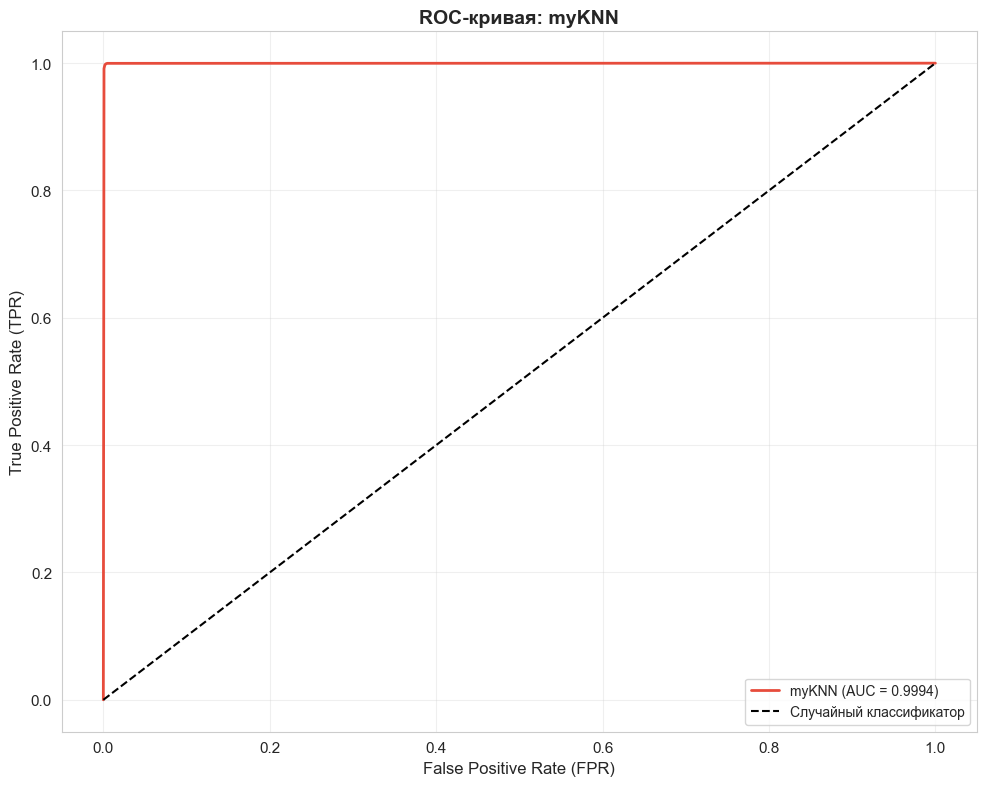

AUC для myKNN: 0.9994
--------------------------------------------------


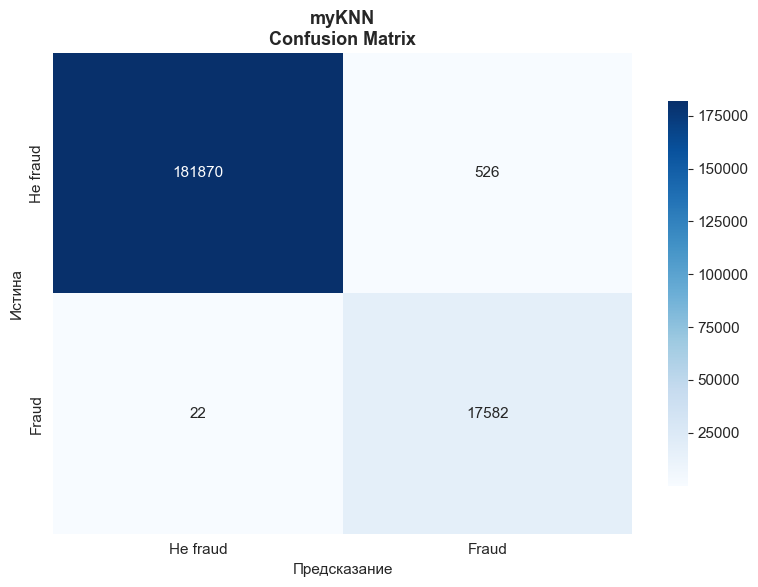


Classification Report для myKNN:
              precision    recall  f1-score   support

    Не fraud       1.00      1.00      1.00    182396
       Fraud       0.97      1.00      0.98     17604

    accuracy                           1.00    200000
   macro avg       0.99      1.00      0.99    200000
weighted avg       1.00      1.00      1.00    200000



In [22]:
model = myknn      #  обученная модель
model_name = 'myKNN'     #  название для графиков

try:
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
except AttributeError:
    from sklearn.preprocessing import MinMaxScaler
    y_proba = model.decision_function(X_test_scaled)
    y_proba = MinMaxScaler().fit_transform(y_proba.reshape(-1, 1)).ravel()

y_pred = model.predict(X_test_scaled)

# ГРАФИК 1: ROC Curve
plt.figure(figsize=(10, 8))
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.plot(fpr, tpr, color='#e74c3c', lw=2, label=f'{model_name} (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Случайный классификатор')

plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title(f'ROC-кривая: {model_name}', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'AUC для {model_name}: {auc:.4f}')
print('-' * 50)

# ГРАФИК 2: Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Не fraud', 'Fraud'],
            yticklabels=['Не fraud', 'Fraud'],
            cbar_kws={'shrink': 0.8})

ax.set_title(f'{model_name}\nConfusion Matrix', fontsize=13, fontweight='bold')
ax.set_xlabel('Предсказание', fontsize=11)
ax.set_ylabel('Истина', fontsize=11)
plt.tight_layout()
plt.show()

# Дополнительные метрики
from sklearn.metrics import classification_report
print(f"\nClassification Report для {model_name}:")
print(classification_report(y_test, y_pred, target_names=['Не fraud', 'Fraud']))

### 4.3 Naive Bayes (GaussianNB)

In [23]:
import numpy as np
import time
import optuna
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, cross_val_score
from scipy.stats import uniform



np.random.seed(42)
nb_search_idx = np.random.choice(len(X_train_bal), size=500000, replace=False)
X_nb_search = X_train_bal[nb_search_idx]
y_nb_search = y_train_bal.iloc[nb_search_idx]

print(f"Размер выборки для поиска: {len(X_nb_search)}\n")

# Параметры (для GaussianNB только var_smoothing)
param_dist_nb = {
    'var_smoothing': uniform(1e-10, 1e-7)
}

param_grid_nb = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6]
}

best_params = {}

# 1. RandomizedSearchCV
print("\n" + "="*70)
print("1. RandomizedSearchCV")
print("="*70)
start_time = time.time()

random_search_nb = RandomizedSearchCV(
    GaussianNB(),
    param_distributions=param_dist_nb,
    n_iter=10,
    scoring='f1',
    cv=3,
    random_state=42,
    n_jobs=-1
)
random_search_nb.fit(X_nb_search, y_nb_search)

best_params['random'] = random_search_nb.best_params_
print(f"Лучшие параметры: {best_params['random']}")
print(f"F1 (CV): {random_search_nb.best_score_:.4f}")
print(f"Время: {(time.time() - start_time)/60:.2f} мин.")

# 2. GridSearchCV
print("\n" + "="*70)
print("2. GridSearchCV")
print("="*70)
start_time = time.time()

grid_search_nb = GridSearchCV(
    GaussianNB(),
    param_grid=param_grid_nb,
    scoring='f1',
    cv=3,
    n_jobs=-1
)
grid_search_nb.fit(X_nb_search, y_nb_search)

best_params['grid'] = grid_search_nb.best_params_
print(f"Лучшие параметры: {best_params['grid']}")
print(f"F1 (CV): {grid_search_nb.best_score_:.4f}")
print(f"Время: {(time.time() - start_time)/60:.2f} мин.")

# 3. Optuna
print("\n" + "="*70)
print("3. Optuna")
print("="*70)

def objective(trial):
    var_smoothing = trial.suggest_float('var_smoothing', 1e-10, 1e-6, log=True)
    
    model = GaussianNB(var_smoothing=var_smoothing)
    scores = cross_val_score(model, X_nb_search, y_nb_search, cv=3, scoring='f1', n_jobs=-1)
    return scores.mean()

start_time = time.time()
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20, show_progress_bar=True)

best_params['optuna'] = study.best_params
print(f"\nЛучшие параметры: {best_params['optuna']}")
print(f"F1 (CV): {study.best_value:.4f}")
print(f"Время: {(time.time() - start_time)/60:.2f} мин.")


Размер выборки для поиска: 500000


1. RandomizedSearchCV
Лучшие параметры: {'var_smoothing': np.float64(3.755401188473625e-08)}
F1 (CV): 0.8763
Время: 0.14 мин.

2. GridSearchCV


[I 2026-05-10 23:08:19,347] A new study created in memory with name: no-name-5d69b326-b928-4027-9485-3eacdfeeaeab


Лучшие параметры: {'var_smoothing': 1e-06}
F1 (CV): 0.8763
Время: 0.01 мин.

3. Optuna


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-05-10 23:08:19,671] Trial 0 finished with value: 0.8762626046706222 and parameters: {'var_smoothing': 1.413956851473341e-09}. Best is trial 0 with value: 0.8762626046706222.
[I 2026-05-10 23:08:20,000] Trial 1 finished with value: 0.8762694331119313 and parameters: {'var_smoothing': 8.083044900379969e-07}. Best is trial 1 with value: 0.8762694331119313.
[I 2026-05-10 23:08:20,312] Trial 2 finished with value: 0.8762626046706222 and parameters: {'var_smoothing': 2.0530420338051792e-09}. Best is trial 1 with value: 0.8762694331119313.
[I 2026-05-10 23:08:20,654] Trial 3 finished with value: 0.8762626046706222 and parameters: {'var_smoothing': 5.4209648062564316e-09}. Best is trial 1 with value: 0.8762694331119313.
[I 2026-05-10 23:08:20,942] Trial 4 finished with value: 0.8762626046706222 and parameters: {'var_smoothing': 2.522536859944653e-10}. Best is trial 1 with value: 0.8762694331119313.
[I 2026-05-10 23:08:21,241] Trial 5 finished with value: 0.8762694331119313 and paramete

In [24]:
from sklearn.naive_bayes import GaussianNB

print("="*70)
print("ОБУЧЕНИЕ ФИНАЛЬНОЙ МОДЕЛИ Naive Bayes (параметры от Optuna)")
print("="*70)

# Берем параметры от Optuna
params = best_params['optuna']

print(f"\nИспользуемые параметры:")
print(f"  var_smoothing: {params['var_smoothing']}")

# Обучаем финальную модель на полном датасете
print(f"\nОбучение на полном датасете ({len(X_train_bal)} объектов)...")
nb_final = GaussianNB(var_smoothing=params['var_smoothing'])
nb_final.fit(X_train_bal, y_train_bal)

print("✓ Модель nb_final обучена!")
print("="*70)

ОБУЧЕНИЕ ФИНАЛЬНОЙ МОДЕЛИ Naive Bayes (параметры от Optuna)

Используемые параметры:
  var_smoothing: 8.083044900379969e-07

Обучение на полном датасете (1095116 объектов)...
✓ Модель nb_final обучена!


In [25]:
y_pred_nb = nb_final.predict(X_test_scaled)
y_proba_nb = nb_final.predict_proba(X_test_scaled)[:, 1]

print("\n" + "="*50)
print("Naive Bayes - результаты на тестовой выборке")
print("="*50)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_nb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_nb):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_nb):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_nb):.4f}")
print(f"ROC AUC:   {roc_auc_score(y_test, y_proba_nb):.4f}")
print(f"\nМатрица ошибок:")
print(confusion_matrix(y_test, y_pred_nb))
print(f"\nОтчёт по классификации:")
print(classification_report(y_test, y_pred_nb, target_names=['Не мошенничество', 'Мошенничество']))


Naive Bayes - результаты на тестовой выборке
Accuracy:  0.6414
Precision: 0.1928
Recall:    0.9643
F1-score:  0.3213
ROC AUC:   0.9655

Матрица ошибок:
[[111304  71092]
 [   629  16975]]

Отчёт по классификации:
                  precision    recall  f1-score   support

Не мошенничество       0.99      0.61      0.76    182396
   Мошенничество       0.19      0.96      0.32     17604

        accuracy                           0.64    200000
       macro avg       0.59      0.79      0.54    200000
    weighted avg       0.92      0.64      0.72    200000



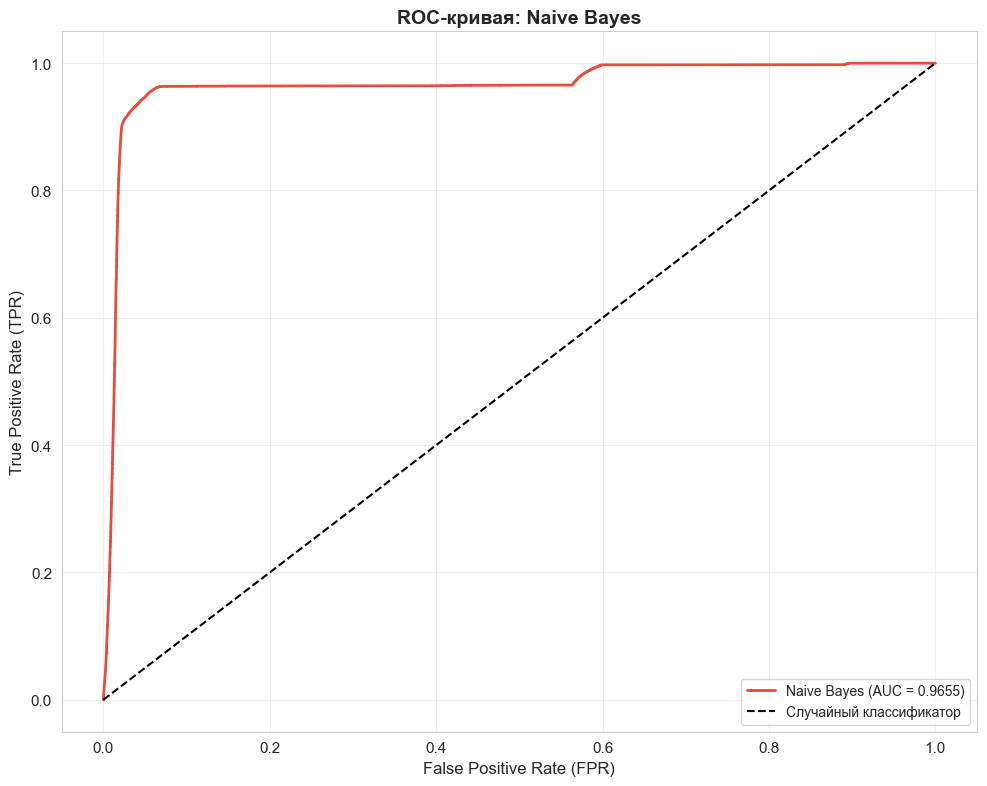

AUC для Naive Bayes: 0.9655
--------------------------------------------------


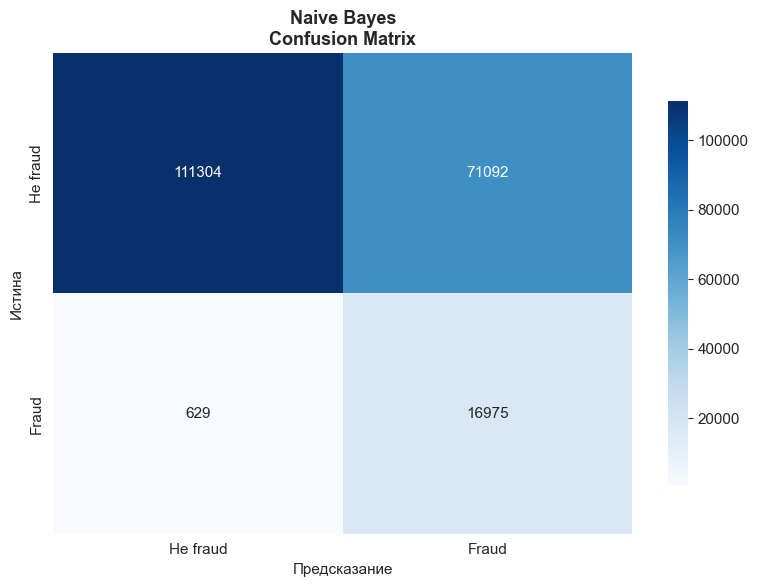


Classification Report для Naive Bayes:
              precision    recall  f1-score   support

    Не fraud       0.99      0.61      0.76    182396
       Fraud       0.19      0.96      0.32     17604

    accuracy                           0.64    200000
   macro avg       0.59      0.79      0.54    200000
weighted avg       0.92      0.64      0.72    200000



In [26]:
model = nb_final      #  ваша обученная модель
model_name = 'Naive Bayes'     #  название для графиков

try:
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
except AttributeError:
    from sklearn.preprocessing import MinMaxScaler
    y_proba = model.decision_function(X_test_scaled)
    y_proba = MinMaxScaler().fit_transform(y_proba.reshape(-1, 1)).ravel()

y_pred = model.predict(X_test_scaled)

# ГРАФИК 1: ROC Curve
plt.figure(figsize=(10, 8))
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.plot(fpr, tpr, color='#e74c3c', lw=2, label=f'{model_name} (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Случайный классификатор')

plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title(f'ROC-кривая: {model_name}', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'AUC для {model_name}: {auc:.4f}')
print('-' * 50)

# ГРАФИК 2: Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Не fraud', 'Fraud'],
            yticklabels=['Не fraud', 'Fraud'],
            cbar_kws={'shrink': 0.8})

ax.set_title(f'{model_name}\nConfusion Matrix', fontsize=13, fontweight='bold')
ax.set_xlabel('Предсказание', fontsize=11)
ax.set_ylabel('Истина', fontsize=11)
plt.tight_layout()
plt.show()

# Дополнительные метрики
from sklearn.metrics import classification_report
print(f"\nClassification Report для {model_name}:")
print(classification_report(y_test, y_pred, target_names=['Не fraud', 'Fraud']))

Такой резкий скачок на ROC-кривой Naive Bayes возникает из-за того, что модель выдает ограниченное количество различных вероятностных оценок, особенно при наличии сильно коррелирующих признаков, что нарушает предположение о независимости. Это приводит к тому, что многие наблюдения получают одинаковые или очень близкие предсказанные вероятности, создавая «ступенчатый» характер кривой вместо плавного перехода. Также такая ситуация возможна при дисбалансе классов или когда модель выдает экстремальные вероятности, близкие к 0 или 1.

### 4.4 SVM

In [27]:
import time
import numpy as np
import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, cross_val_score
from scipy.stats import uniform, randint
import optuna
from optuna.samplers import TPESampler
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print("ПОДБОР ГИПЕРПАРАМЕТРОВ SVM (5 ЯДЕР × 3 МЕТОДА)")
print("="*70)

np.random.seed(42)
svm_idx = np.random.choice(len(X_train_bal), size=30000, replace=False)
X_svm_search = X_train_bal[svm_idx]
y_svm_search = y_train_bal.iloc[svm_idx]

print(f"Используем выборку из {len(X_svm_search)} объектов.")

# Конфигурации для разных ядер
kernels_config = {
    'linear': {
        'random': {
            'kernel': ['linear'],
            'C': uniform(0.1, 100)
        },
        'grid': {
            'kernel': ['linear'],
            'C': [0.1, 0.5, 1, 5, 10, 50, 100]
        },
        'optuna': 'linear'
    },
    'poly': {
        'random': {
            'kernel': ['poly'],
            'C': uniform(0.1, 50),
            'degree': [2, 3],
            'gamma': ['scale', 'auto'],
            'coef0': uniform(0, 1)
        },
        'grid': {
            'kernel': ['poly'],
            'C': [0.1, 1, 10, 50],
            'degree': [2, 3],
            'gamma': ['scale', 'auto'],
            'coef0': [0, 0.5, 1]
        },
        'optuna': 'poly'
    },
    'rbf': {
        'random': {
            'kernel': ['rbf'],
            'C': uniform(0.1, 50),
            'gamma': ['scale', 'auto', 0.001, 0.01, 0.1]
        },
        'grid': {
            'kernel': ['rbf'],
            'C': [0.1, 1, 10, 50],
            'gamma': ['scale', 'auto', 0.001, 0.01, 0.1]
        },
        'optuna': 'rbf'
    },
    'sigmoid': {
        'random': {
            'kernel': ['sigmoid'],
            'C': uniform(0.1, 50),
            'gamma': ['scale', 'auto', 0.001, 0.01],
            'coef0': uniform(-1, 2)
        },
        'grid': {
            'kernel': ['sigmoid'],
            'C': [0.1, 1, 10, 50],
            'gamma': ['scale', 'auto', 0.001, 0.01],
            'coef0': [-1, 0, 1]
        },
        'optuna': 'sigmoid'
    }
}

# Словари для хранения результатов
results = {kernel: {} for kernel in kernels_config}
final_models = {kernel: {} for kernel in kernels_config}
start_total = time.time()

# Функция для Optuna
def objective_linear(trial):
    C = trial.suggest_float('C', 0.1, 100, log=True)
    model = SVC(kernel='linear', C=C, random_state=42, probability=True)
    return cross_val_score(model, X_svm_search, y_svm_search, cv=3, scoring='f1').mean()

def objective_poly(trial):
    C = trial.suggest_float('C', 0.1, 50, log=True)
    degree = trial.suggest_int('degree', 2, 4)
    gamma = trial.suggest_categorical('gamma', ['scale', 'auto'])
    coef0 = trial.suggest_float('coef0', 0, 1)
    model = SVC(kernel='poly', C=C, degree=degree, gamma=gamma, coef0=coef0, random_state=42, probability=True)
    return cross_val_score(model, X_svm_search, y_svm_search, cv=3, scoring='f1').mean()

def objective_rbf(trial):
    C = trial.suggest_float('C', 0.1, 50, log=True)
    gamma = trial.suggest_categorical('gamma', ['scale', 'auto', 0.001, 0.01, 0.1])
    model = SVC(kernel='rbf', C=C, gamma=gamma, random_state=42, probability=True)
    return cross_val_score(model, X_svm_search, y_svm_search, cv=3, scoring='f1').mean()

def objective_sigmoid(trial):
    C = trial.suggest_float('C', 0.1, 50, log=True)
    gamma = trial.suggest_categorical('gamma', ['scale', 'auto', 0.001, 0.01])
    coef0 = trial.suggest_float('coef0', -1, 1)
    model = SVC(kernel='sigmoid', C=C, gamma=gamma, coef0=coef0, random_state=42, probability=True)
    return cross_val_score(model, X_svm_search, y_svm_search, cv=3, scoring='f1').mean()

objective_functions = {
    'linear': objective_linear,
    'poly': objective_poly,
    'rbf': objective_rbf,
    'sigmoid': objective_sigmoid
}

# Цикл по ядрам
for kernel_name in kernels_config:
    print(f"\n{'='*70}")
    print(f"ЯДРО: {kernel_name.upper()}")
    print(f"{'='*70}")
    
    # 1. RandomizedSearchCV
    print(f"\n{'─'*50}")
    print(f"1. RandomizedSearchCV")
    print(f"{'─'*50}")
    start_time = time.time()
    
    try:
        random_search = RandomizedSearchCV(
            SVC(random_state=42, probability=True),
            param_distributions=kernels_config[kernel_name]['random'],
            n_iter=5,
            scoring='f1',
            cv=3,
            random_state=42,
            n_jobs=-1
        )
        random_search.fit(X_svm_search, y_svm_search)
        results[kernel_name]['random'] = {
            'score': random_search.best_score_,
            'params': random_search.best_params_,
            'time': time.time() - start_time
        }
        final_models[kernel_name]['random'] = random_search.best_estimator_
        print(f"✓ F1: {random_search.best_score_:.4f}")
        print(f"  Параметры: {random_search.best_params_}")
        print(f"  Время: {(time.time() - start_time)/60:.2f} мин")
    except Exception as e:
        print(f"✗ Ошибка: {e}")
        results[kernel_name]['random'] = {'score': 0, 'error': str(e)}
    
    # 2. GridSearchCV
    print(f"\n{'─'*50}")
    print(f"2. GridSearchCV")
    print(f"{'─'*50}")
    start_time = time.time()
    
    try:
        grid_search = GridSearchCV(
            SVC(random_state=42, probability=True),
            param_grid=kernels_config[kernel_name]['grid'],
            scoring='f1',
            cv=3,
            n_jobs=-1
        )
        grid_search.fit(X_svm_search, y_svm_search)
        results[kernel_name]['grid'] = {
            'score': grid_search.best_score_,
            'params': grid_search.best_params_,
            'time': time.time() - start_time
        }
        final_models[kernel_name]['grid'] = grid_search.best_estimator_
        print(f"✓ F1: {grid_search.best_score_:.4f}")
        print(f"  Параметры: {grid_search.best_params_}")
        print(f"  Время: {(time.time() - start_time)/60:.2f} мин")
    except Exception as e:
        print(f"✗ Ошибка: {e}")
        results[kernel_name]['grid'] = {'score': 0, 'error': str(e)}
    
    # 3. Optuna
    print(f"\n{'─'*50}")
    print(f"3. Optuna")
    print(f"{'─'*50}")
    start_time = time.time()
    
    try:
        study = optuna.create_study(
            direction='maximize',
            sampler=TPESampler(seed=42),
            study_name=f'svm_{kernel_name}'
        )
        study.optimize(
            objective_functions[kernel_name],
            n_trials=20,
            show_progress_bar=True
        )
        
        # Создаем модель с лучшими параметрами
        best_params = study.best_params
        if kernel_name == 'linear':
            best_model = SVC(kernel='linear', C=best_params['C'], random_state=42, probability=True)
        elif kernel_name == 'poly':
            best_model = SVC(kernel='poly', C=best_params['C'], 
                           degree=best_params['degree'],
                           gamma=best_params.get('gamma', 'scale'),
                           coef0=best_params.get('coef0', 0), random_state=42, probability=True)
        elif kernel_name == 'rbf':
            best_model = SVC(kernel='rbf', C=best_params['C'],
                           gamma=best_params.get('gamma', 'scale'), random_state=42, probability=True)
        elif kernel_name == 'sigmoid':
            best_model = SVC(kernel='sigmoid', C=best_params['C'],
                           gamma=best_params.get('gamma', 'scale'),
                           coef0=best_params.get('coef0', 0), random_state=42, probability=True)
        
        best_model.fit(X_svm_search, y_svm_search)
        
        results[kernel_name]['optuna'] = {
            'score': study.best_value,
            'params': study.best_params,
            'time': time.time() - start_time
        }
        final_models[kernel_name]['optuna'] = best_model
        print(f"✓ F1: {study.best_value:.4f}")
        print(f"  Параметры: {study.best_params}")
        print(f"  Время: {(time.time() - start_time)/60:.2f} мин")
    except Exception as e:
        print(f"✗ Ошибка: {e}")
        results[kernel_name]['optuna'] = {'score': 0, 'error': str(e)}

# Сводная таблица результатов
print(f"\n{'='*70}")
print("СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")
print(f"{'='*70}")

summary_data = []
for kernel in kernels_config:
    for method in ['random', 'grid', 'optuna']:
        if 'error' not in results[kernel][method]:
            summary_data.append({
                'Ядро': kernel,
                'Метод': method,
                'F1': f"{results[kernel][method]['score']:.4f}",
                'Время (мин)': f"{results[kernel][method]['time']/60:.2f}"
            })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

# Определение лучшего метода для каждого ядра
print(f"\n{'='*70}")
print("ЛУЧШИЕ МЕТОДЫ ДЛЯ КАЖДОГО ЯДРА")
print(f"{'='*70}")

for kernel in kernels_config:
    best_method = max(
        [m for m in ['random', 'grid', 'optuna'] if 'error' not in results[kernel][m]],
        key=lambda m: results[kernel][m]['score']
    )
    print(f"\n{kernel.upper()}: {best_method.upper()}")
    print(f"  F1: {results[kernel][best_method]['score']:.4f}")
    print(f"  Параметры: {results[kernel][best_method]['params']}")

print(f"\nОбщее время выполнения: {(time.time() - start_total)/60:.2f} мин")

ПОДБОР ГИПЕРПАРАМЕТРОВ SVM (5 ЯДЕР × 3 МЕТОДА)
Используем выборку из 30000 объектов.

ЯДРО: LINEAR

──────────────────────────────────────────────────
1. RandomizedSearchCV
──────────────────────────────────────────────────
✓ F1: 0.9479
  Параметры: {'C': np.float64(73.2993941811405), 'kernel': 'linear'}
  Время: 3.39 мин

──────────────────────────────────────────────────
2. GridSearchCV
──────────────────────────────────────────────────


[I 2026-05-10 23:13:43,432] A new study created in memory with name: svm_linear


✓ F1: 0.9481
  Параметры: {'C': 1, 'kernel': 'linear'}
  Время: 1.90 мин

──────────────────────────────────────────────────
3. Optuna
──────────────────────────────────────────────────


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-05-10 23:14:06,699] Trial 0 finished with value: 0.9479418835980811 and parameters: {'C': 1.3292918943162166}. Best is trial 0 with value: 0.9479418835980811.
[I 2026-05-10 23:16:18,976] Trial 1 finished with value: 0.9479173149954386 and parameters: {'C': 71.14476009343416}. Best is trial 0 with value: 0.9479418835980811.
[I 2026-05-10 23:17:13,468] Trial 2 finished with value: 0.9478824602353164 and parameters: {'C': 15.702970884055382}. Best is trial 0 with value: 0.9479418835980811.
[I 2026-05-10 23:17:49,565] Trial 3 finished with value: 0.9479484864477228 and parameters: {'C': 6.2513735745217485}. Best is trial 3 with value: 0.9479484864477228.
[I 2026-05-10 23:18:07,685] Trial 4 finished with value: 0.9479070957639809 and parameters: {'C': 0.2938027938703535}. Best is trial 3 with value: 0.9479484864477228.
[I 2026-05-10 23:18:25,892] Trial 5 finished with value: 0.9478723430606601 and parameters: {'C': 0.2937538457632829}. Best is trial 3 with value: 0.9479484864477228.

...

[I 2026-05-10 23:37:22,401] Trial 0 finished with value: 0.9859726789553775 and parameters: {'C': 1.025350969016849, 'gamma': 'scale'}. Best is trial 0 with value: 0.9859726789553775.
[I 2026-05-10 23:37:42,956] Trial 1 finished with value: 0.9787626234593536 and parameters: {'C': 0.1434715951720141, 'gamma': 0.1}. Best is trial 0 with value: 0.9859726789553775.
[I 2026-05-10 23:37:48,451] Trial 2 finished with value: 0.9939004089060409 and parameters: {'C': 17.64971584817571, 'gamma': 0.1}. Best is trial 2 with value: 0.9939004089060409.
[I 2026-05-10 23:37:57,245] Trial 3 finished with value: 0.9904459173762824 and parameters: {'C': 1.464895513280072, 'gamma': 'auto'}. Best is trial 2 with value: 0.9939004089060409.
[I 2026-05-10 23:38:07,319] Trial 4 finished with value: 0.9878561985620303 and parameters: {'C': 1.7018418817029164, 'gamma': 'scale'}. Best is trial 2 with value: 0.9939004089060409.
[I 2026-05-10 23:38:26,961] Trial 5 finished with value: 0.9689944237754827 and paramet

[I 2026-05-10 23:47:12,762] A new study created in memory with name: svm_sigmoid


✓ F1: 0.9519
  Параметры: {'C': 10, 'coef0': -1, 'gamma': 0.01, 'kernel': 'sigmoid'}
  Время: 5.35 мин

──────────────────────────────────────────────────
3. Optuna
──────────────────────────────────────────────────


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-05-10 23:47:29,982] Trial 0 finished with value: 0.9111933589147981 and parameters: {'C': 1.025350969016849, 'gamma': 'scale', 'coef0': -0.6880109593275947}. Best is trial 0 with value: 0.9111933589147981.
[I 2026-05-10 23:48:14,137] Trial 1 finished with value: 0.7989758146873814 and parameters: {'C': 0.1434715951720141, 'gamma': 'scale', 'coef0': 0.9398197043239886}. Best is trial 0 with value: 0.9111933589147981.
[I 2026-05-10 23:48:27,765] Trial 2 finished with value: 0.9161072327137024 and parameters: {'C': 17.64971584817571, 'gamma': 0.01, 'coef0': 0.04951286326447568}. Best is trial 2 with value: 0.9161072327137024.
[I 2026-05-10 23:48:51,256] Trial 3 finished with value: 0.8586185810864859 and parameters: {'C': 1.464895513280072, 'gamma': 'auto', 'coef0': -0.2672763134126166}. Best is trial 2 with value: 0.9161072327137024.
[I 2026-05-10 23:49:13,304] Trial 4 finished with value: 0.9063326874870302 and parameters: {'C': 1.7018418817029164, 'gamma': 'scale', 'coef0': -0.

# ЛИНЕЙНАЯ

In [64]:
print("="*70)
print("ОБУЧЕНИЕ ФИНАЛЬНОЙ МОДЕЛИ SVM (L ЯДРО)")
print("="*70)

svm_final_L = final_models['linear']['grid'] 

print("✓ Модель svm_final_L ")
print(f"  kernel: {svm_final_L.kernel}")
print(f"  C: {svm_final_L.C}")
print(f"  class_weight: {svm_final_L.class_weight}")

svm_idx = np.random.choice(len(X_train_bal), size=100000, replace=False)
X_svm_search = X_train_bal[svm_idx]
y_svm_search = y_train_bal.iloc[svm_idx]

svm_final_L.fit(X_svm_search, y_svm_search)

print("✓ Модель svm_final_L готова!")
print("="*70)

ОБУЧЕНИЕ ФИНАЛЬНОЙ МОДЕЛИ SVM (L ЯДРО)
✓ Модель svm_final_L 
  kernel: linear
  C: 1
  class_weight: None
✓ Модель svm_final_L готова!


In [65]:
# Оценка SVM на test
y_pred_svm_L = svm_final_L.predict(X_test_scaled)
y_proba_svm_L = svm_final_L.predict_proba(X_test_scaled)[:, 1]

print("\n" + "="*50)
print("SVM — результаты на тестовой выборке")
print("="*50)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_svm_L):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_svm_L):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_svm_L):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_svm_L):.4f}")
print(f"ROC AUC:   {roc_auc_score(y_test, y_proba_svm_L):.4f}")
print(f"\nМатрица ошибок:")
print(confusion_matrix(y_test, y_pred_svm_L))
print(f"\nОтчёт по классификации:")
print(classification_report(y_test, y_pred_svm_L, target_names=['Не мошенничество', 'Мошенничество']))


SVM — результаты на тестовой выборке
Accuracy:  0.9314
Precision: 0.5644
Recall:    0.9660
F1-score:  0.7125
ROC AUC:   0.9795

Матрица ошибок:
[[169271  13125]
 [   599  17005]]

Отчёт по классификации:
                  precision    recall  f1-score   support

Не мошенничество       1.00      0.93      0.96    182396
   Мошенничество       0.56      0.97      0.71     17604

        accuracy                           0.93    200000
       macro avg       0.78      0.95      0.84    200000
    weighted avg       0.96      0.93      0.94    200000



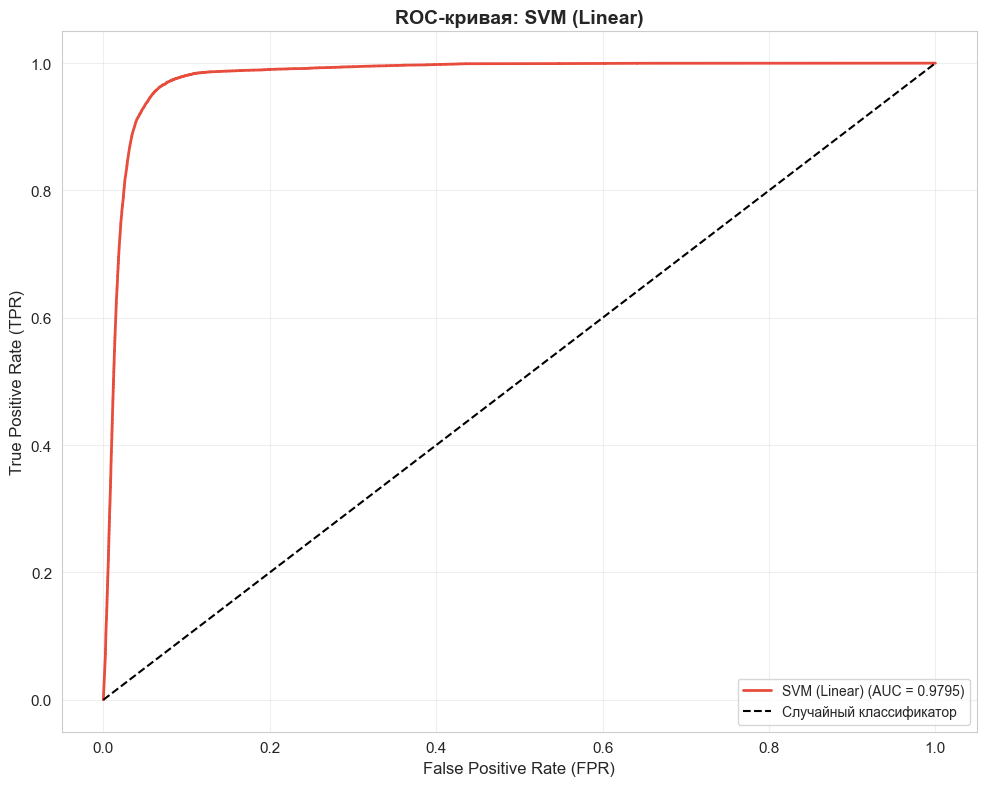

AUC для SVM (Linear): 0.9795
--------------------------------------------------


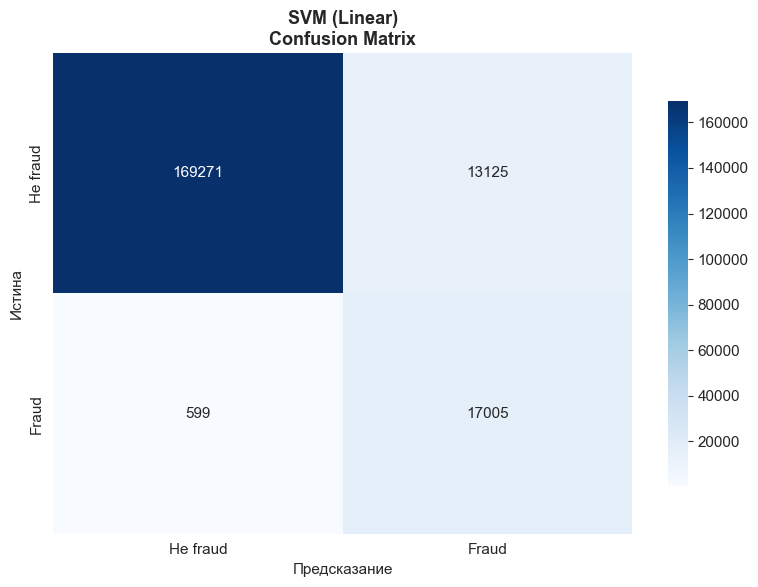


Classification Report для SVM (Linear):
              precision    recall  f1-score   support

    Не fraud       1.00      0.93      0.96    182396
       Fraud       0.56      0.97      0.71     17604

    accuracy                           0.93    200000
   macro avg       0.78      0.95      0.84    200000
weighted avg       0.96      0.93      0.94    200000



In [66]:
model = svm_final_L
model_name = 'SVM (Linear)'

try:
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
except AttributeError:
    from sklearn.preprocessing import MinMaxScaler
    y_proba = model.decision_function(X_test_scaled)
    y_proba = MinMaxScaler().fit_transform(y_proba.reshape(-1, 1)).ravel()

y_pred = model.predict(X_test_scaled)

# ГРАФИК 1: ROC Curve
plt.figure(figsize=(10, 8))
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.plot(fpr, tpr, color='#e74c3c', lw=2, label=f'{model_name} (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Случайный классификатор')

plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title(f'ROC-кривая: {model_name}', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'AUC для {model_name}: {auc:.4f}')
print('-' * 50)

# ГРАФИК 2: Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Не fraud', 'Fraud'],
            yticklabels=['Не fraud', 'Fraud'],
            cbar_kws={'shrink': 0.8})

ax.set_title(f'{model_name}\nConfusion Matrix', fontsize=13, fontweight='bold')
ax.set_xlabel('Предсказание', fontsize=11)
ax.set_ylabel('Истина', fontsize=11)
plt.tight_layout()
plt.show()

# Дополнительные метрики
from sklearn.metrics import classification_report
print(f"\nClassification Report для {model_name}:")
print(classification_report(y_test, y_pred, target_names=['Не fraud', 'Fraud']))

# RBF

In [67]:
print("="*70)
print("ОБУЧЕНИЕ ФИНАЛЬНОЙ МОДЕЛИ SVM (RBF ЯДРО)")
print("="*70)

# Берем готовую модель из final_models
svm_final_rbf = final_models['rbf']['grid']

print("✓ Модель svm_final_rbf взята из final_models['rbf']")
print(f"  kernel: {svm_final_rbf.kernel}")
print(f"  C: {svm_final_rbf.C}")
print(f"  class_weight: {svm_final_rbf.class_weight}")

svm_idx = np.random.choice(len(X_train_bal), size=50000, replace=False)
X_svm_search = X_train_bal[svm_idx]
y_svm_search = y_train_bal.iloc[svm_idx]

svm_final_rbf.fit(X_svm_search, y_svm_search)

print("✓ Модель svm_final_rbf готова!")
print("="*70)

ОБУЧЕНИЕ ФИНАЛЬНОЙ МОДЕЛИ SVM (RBF ЯДРО)
✓ Модель svm_final_rbf взята из final_models['rbf']
  kernel: rbf
  C: 50
  class_weight: None
✓ Модель svm_final_rbf готова!


In [68]:
# Оценка SVM на test
y_pred_svm_rbf = svm_final_rbf.predict(X_test_scaled)
y_proba_svm_rbf = svm_final_rbf.predict_proba(X_test_scaled)[:, 1]

print("\n" + "="*50)
print("SVM — результаты на тестовой выборке")
print("="*50)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_svm_rbf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_svm_rbf):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_svm_rbf):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_svm_rbf):.4f}")
print(f"ROC AUC:   {roc_auc_score(y_test, y_proba_svm_rbf):.4f}")
print(f"\nМатрица ошибок:")
print(confusion_matrix(y_test, y_pred_svm_rbf))
print(f"\nОтчёт по классификации:")
print(classification_report(y_test, y_pred_svm_rbf, target_names=['Не мошенничество', 'Мошенничество']))


SVM — результаты на тестовой выборке
Accuracy:  0.9942
Precision: 0.9405
Recall:    0.9978
F1-score:  0.9683
ROC AUC:   0.9999

Матрица ошибок:
[[181284   1112]
 [    38  17566]]

Отчёт по классификации:
                  precision    recall  f1-score   support

Не мошенничество       1.00      0.99      1.00    182396
   Мошенничество       0.94      1.00      0.97     17604

        accuracy                           0.99    200000
       macro avg       0.97      1.00      0.98    200000
    weighted avg       0.99      0.99      0.99    200000



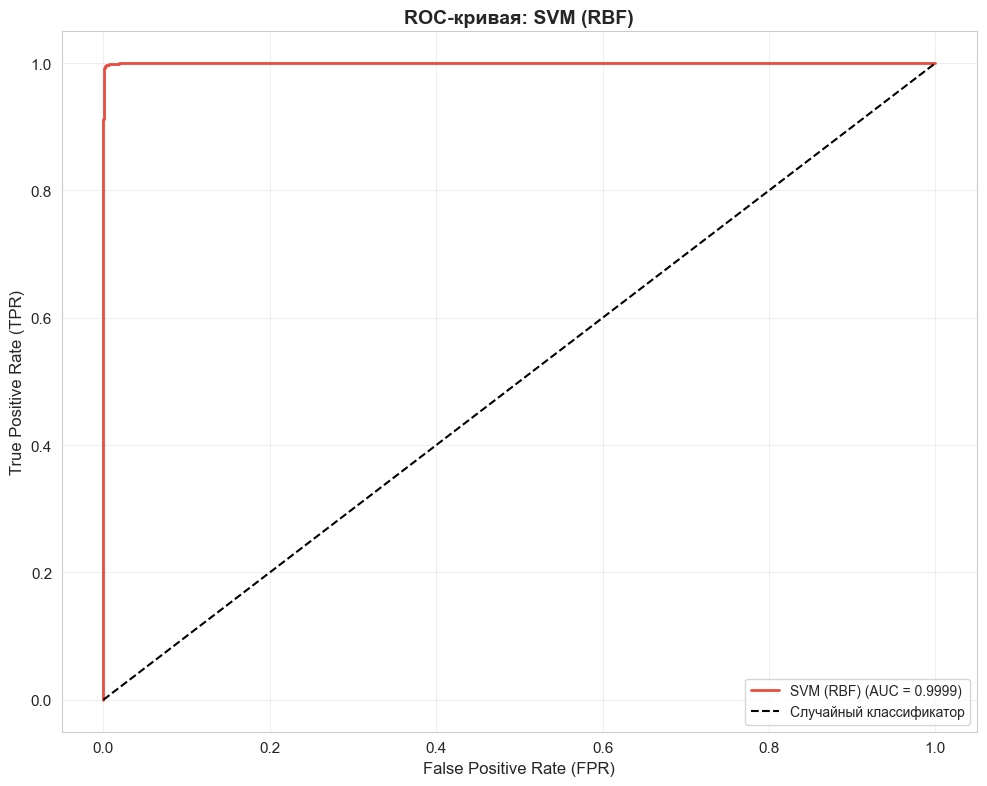

AUC для SVM (RBF): 0.9999
--------------------------------------------------


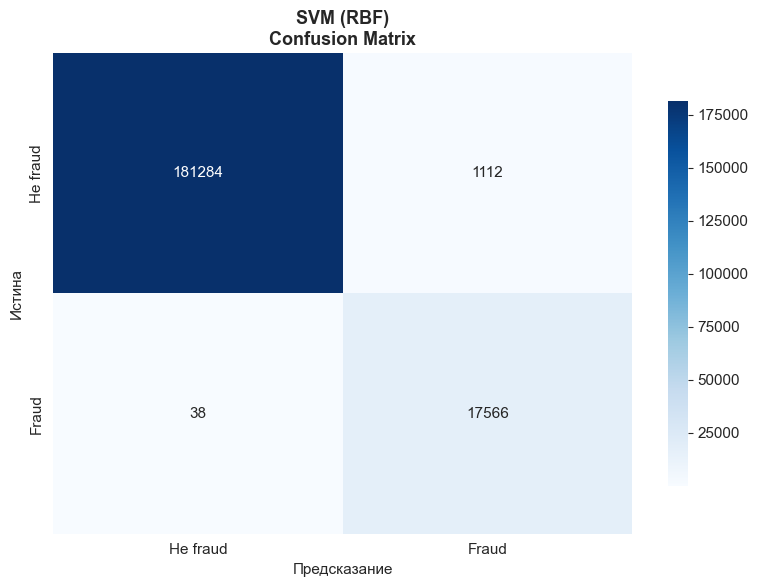


Classification Report для SVM (RBF):
              precision    recall  f1-score   support

    Не fraud       1.00      0.99      1.00    182396
       Fraud       0.94      1.00      0.97     17604

    accuracy                           0.99    200000
   macro avg       0.97      1.00      0.98    200000
weighted avg       0.99      0.99      0.99    200000



In [69]:
model = svm_final_rbf      #  ваша обученная модель
model_name = 'SVM (RBF)'     #  название для графиков

try:
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
except AttributeError:
    from sklearn.preprocessing import MinMaxScaler
    y_proba = model.decision_function(X_test_scaled)
    y_proba = MinMaxScaler().fit_transform(y_proba.reshape(-1, 1)).ravel()

y_pred = model.predict(X_test_scaled)

# ГРАФИК 1: ROC Curve
plt.figure(figsize=(10, 8))
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.plot(fpr, tpr, color='#e74c3c', lw=2, label=f'{model_name} (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Случайный классификатор')

plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title(f'ROC-кривая: {model_name}', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'AUC для {model_name}: {auc:.4f}')
print('-' * 50)

# ГРАФИК 2: Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Не fraud', 'Fraud'],
            yticklabels=['Не fraud', 'Fraud'],
            cbar_kws={'shrink': 0.8})

ax.set_title(f'{model_name}\nConfusion Matrix', fontsize=13, fontweight='bold')
ax.set_xlabel('Предсказание', fontsize=11)
ax.set_ylabel('Истина', fontsize=11)
plt.tight_layout()
plt.show()

# Дополнительные метрики
from sklearn.metrics import classification_report
print(f"\nClassification Report для {model_name}:")
print(classification_report(y_test, y_pred, target_names=['Не fraud', 'Fraud']))

# POLY

In [70]:
print("="*70)
print("ОБУЧЕНИЕ ФИНАЛЬНОЙ МОДЕЛИ SVM (POLY ЯДРО)")
print("="*70)

svm_final_poly = final_models['poly']['grid']

print("✓ Модель svm_final_poly взята из final_models['poly']")
print(f"  kernel: {svm_final_poly.kernel}")
print(f"  C: {svm_final_poly.C}")
print(f"  class_weight: {svm_final_poly.class_weight}")

svm_idx = np.random.choice(len(X_train_bal), size=50000, replace=False)
X_svm_search = X_train_bal[svm_idx]
y_svm_search = y_train_bal.iloc[svm_idx]

svm_final_poly.fit(X_svm_search, y_svm_search)

print("✓ Модель svm_final_poly готова!")
print("="*70)

ОБУЧЕНИЕ ФИНАЛЬНОЙ МОДЕЛИ SVM (POLY ЯДРО)
✓ Модель svm_final_poly взята из final_models['poly']
  kernel: poly
  C: 50
  class_weight: None
✓ Модель svm_final_poly готова!


In [71]:
# Оценка SVM на test
y_pred_svm_poly = svm_final_poly.predict(X_test_scaled)
y_proba_svm_poly = svm_final_poly.predict_proba(X_test_scaled)[:, 1]

print("\n" + "="*50)
print("SVM — результаты на тестовой выборке")
print("="*50)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_svm_poly):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_svm_poly):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_svm_poly):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_svm_poly):.4f}")
print(f"ROC AUC:   {roc_auc_score(y_test, y_proba_svm_poly):.4f}")
print(f"\nМатрица ошибок:")
print(confusion_matrix(y_test, y_pred_svm_poly))
print(f"\nОтчёт по классификации:")
print(classification_report(y_test, y_pred_svm_poly, target_names=['Не мошенничество', 'Мошенничество']))


SVM — результаты на тестовой выборке
Accuracy:  0.9928
Precision: 0.9269
Recall:    0.9968
F1-score:  0.9606
ROC AUC:   0.9991

Матрица ошибок:
[[181012   1384]
 [    56  17548]]

Отчёт по классификации:
                  precision    recall  f1-score   support

Не мошенничество       1.00      0.99      1.00    182396
   Мошенничество       0.93      1.00      0.96     17604

        accuracy                           0.99    200000
       macro avg       0.96      0.99      0.98    200000
    weighted avg       0.99      0.99      0.99    200000



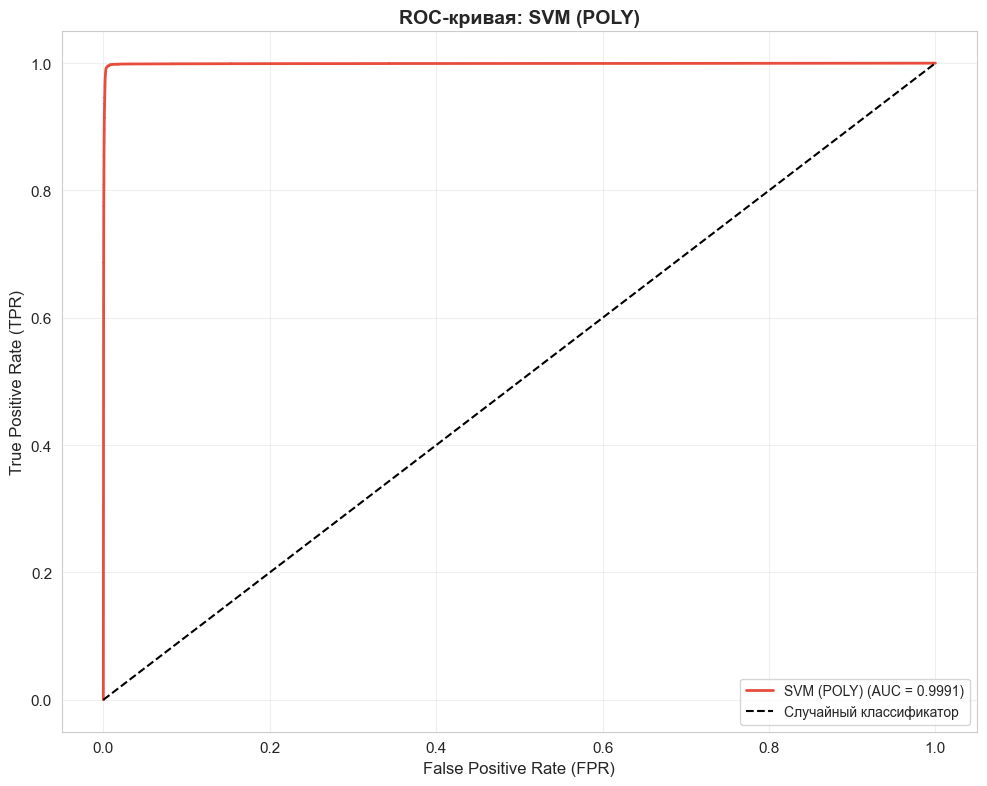

AUC для SVM (POLY): 0.9991
--------------------------------------------------


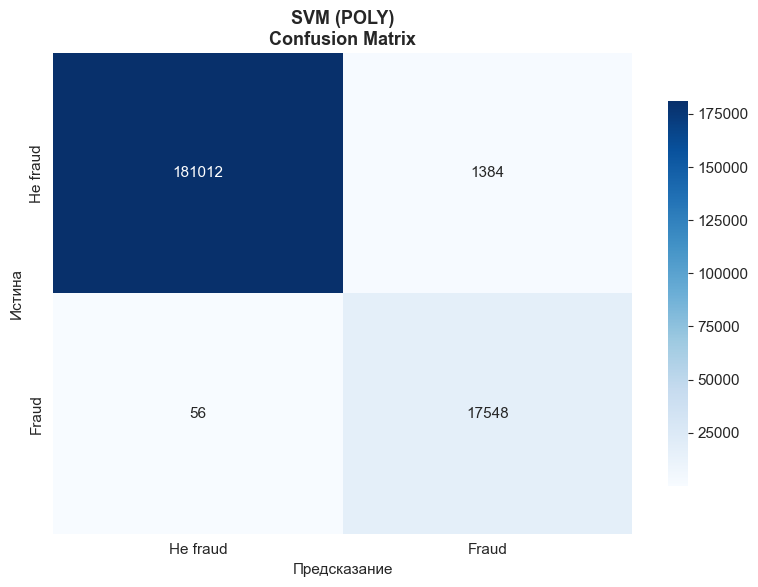


Classification Report для SVM (POLY):
              precision    recall  f1-score   support

    Не fraud       1.00      0.99      1.00    182396
       Fraud       0.93      1.00      0.96     17604

    accuracy                           0.99    200000
   macro avg       0.96      0.99      0.98    200000
weighted avg       0.99      0.99      0.99    200000



In [72]:
model = svm_final_poly      #  ваша обученная модель
model_name = 'SVM (POLY)'     #  название для графиков

try:
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
except AttributeError:
    from sklearn.preprocessing import MinMaxScaler
    y_proba = model.decision_function(X_test_scaled)
    y_proba = MinMaxScaler().fit_transform(y_proba.reshape(-1, 1)).ravel()

y_pred = model.predict(X_test_scaled)

# ГРАФИК 1: ROC Curve
plt.figure(figsize=(10, 8))
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.plot(fpr, tpr, color='#e74c3c', lw=2, label=f'{model_name} (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Случайный классификатор')

plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title(f'ROC-кривая: {model_name}', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'AUC для {model_name}: {auc:.4f}')
print('-' * 50)

# ГРАФИК 2: Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Не fraud', 'Fraud'],
            yticklabels=['Не fraud', 'Fraud'],
            cbar_kws={'shrink': 0.8})

ax.set_title(f'{model_name}\nConfusion Matrix', fontsize=13, fontweight='bold')
ax.set_xlabel('Предсказание', fontsize=11)
ax.set_ylabel('Истина', fontsize=11)
plt.tight_layout()
plt.show()

# Дополнительные метрики
from sklearn.metrics import classification_report
print(f"\nClassification Report для {model_name}:")
print(classification_report(y_test, y_pred, target_names=['Не fraud', 'Fraud']))

# SIGMOID

In [73]:
print("="*70)
print("ОБУЧЕНИЕ ФИНАЛЬНОЙ МОДЕЛИ SVM (SIGMOID ЯДРО)")
print("="*70)

svm_final_sigmoid = final_models['sigmoid']['random']

print("✓ Модель svm_final_sigmoid взята из final_models['sigmoid']")
print(f"  kernel: {svm_final_sigmoid.kernel}")
print(f"  C: {svm_final_sigmoid.C}")
print(f"  class_weight: {svm_final_sigmoid.class_weight}")

svm_idx = np.random.choice(len(X_train_bal), size=50000, replace=False)
X_svm_search = X_train_bal[svm_idx]
y_svm_search = y_train_bal.iloc[svm_idx]

svm_final_sigmoid.fit(X_svm_search, y_svm_search)

print("✓ Модель svm_final_sigmoid готова!")
print("="*70)

ОБУЧЕНИЕ ФИНАЛЬНОЙ МОДЕЛИ SVM (SIGMOID ЯДРО)
✓ Модель svm_final_sigmoid взята из final_models['sigmoid']
  kernel: sigmoid
  C: 7.899726016810132
  class_weight: None
✓ Модель svm_final_sigmoid готова!


In [74]:
# Оценка SVM на test
y_pred_svm_sigmoid = svm_final_sigmoid.predict(X_test_scaled)
y_proba_svm_sigmoid = svm_final_sigmoid.predict_proba(X_test_scaled)[:, 1]

print("\n" + "="*50)
print("SVM — результаты на тестовой выборке")
print("="*50)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_svm_sigmoid):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_svm_sigmoid):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_svm_sigmoid):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_svm_sigmoid):.4f}")
print(f"ROC AUC:   {roc_auc_score(y_test, y_proba_svm_sigmoid):.4f}")
print(f"\nМатрица ошибок:")
print(confusion_matrix(y_test, y_pred_svm_sigmoid))
print(f"\nОтчёт по классификации:")
print(classification_report(y_test, y_pred_svm_sigmoid, target_names=['Не мошенничество', 'Мошенничество']))


SVM — результаты на тестовой выборке
Accuracy:  0.9560
Precision: 0.6729
Recall:    0.9728
F1-score:  0.7955
ROC AUC:   0.9792

Матрица ошибок:
[[174070   8326]
 [   479  17125]]

Отчёт по классификации:
                  precision    recall  f1-score   support

Не мошенничество       1.00      0.95      0.98    182396
   Мошенничество       0.67      0.97      0.80     17604

        accuracy                           0.96    200000
       macro avg       0.84      0.96      0.89    200000
    weighted avg       0.97      0.96      0.96    200000



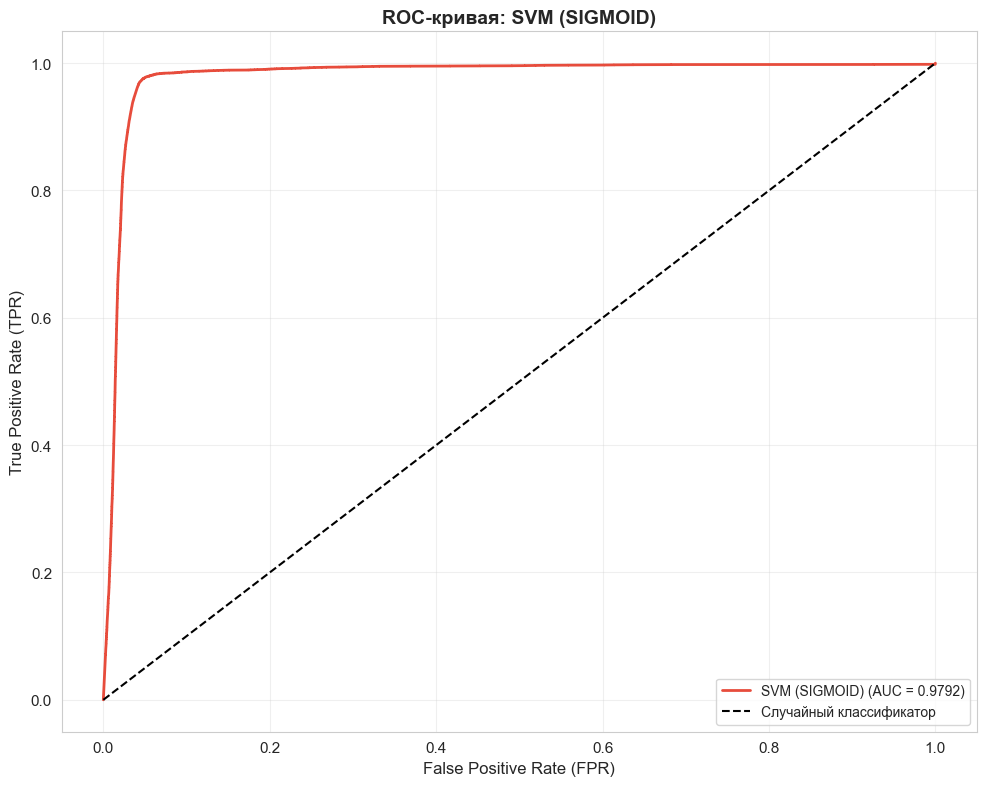

AUC для SVM (SIGMOID): 0.9792
--------------------------------------------------


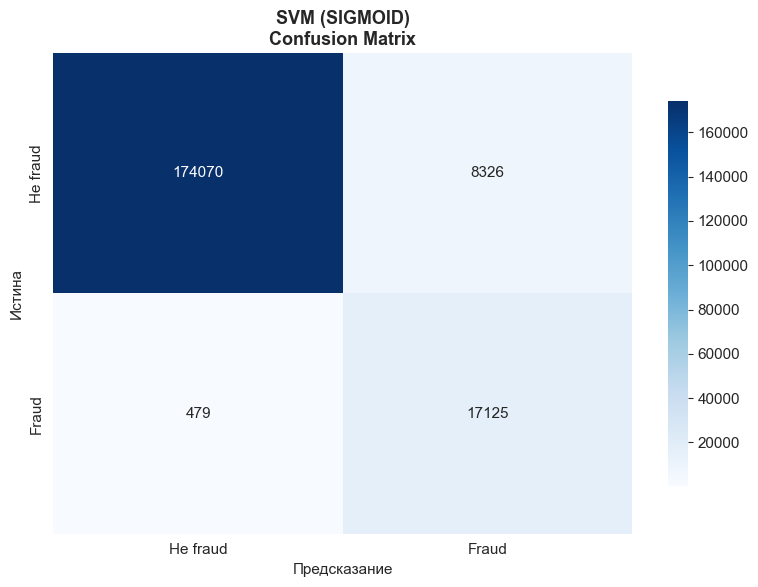


Classification Report для SVM (SIGMOID):
              precision    recall  f1-score   support

    Не fraud       1.00      0.95      0.98    182396
       Fraud       0.67      0.97      0.80     17604

    accuracy                           0.96    200000
   macro avg       0.84      0.96      0.89    200000
weighted avg       0.97      0.96      0.96    200000



In [75]:
model = svm_final_sigmoid
model_name = 'SVM (SIGMOID)'

try:
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
except AttributeError:
    from sklearn.preprocessing import MinMaxScaler
    y_proba = model.decision_function(X_test_scaled)
    y_proba = MinMaxScaler().fit_transform(y_proba.reshape(-1, 1)).ravel()

y_pred = model.predict(X_test_scaled)

# ГРАФИК 1: ROC Curve
plt.figure(figsize=(10, 8))
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.plot(fpr, tpr, color='#e74c3c', lw=2, label=f'{model_name} (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Случайный классификатор')

plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title(f'ROC-кривая: {model_name}', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'AUC для {model_name}: {auc:.4f}')
print('-' * 50)

# ГРАФИК 2: Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Не fraud', 'Fraud'],
            yticklabels=['Не fraud', 'Fraud'],
            cbar_kws={'shrink': 0.8})

ax.set_title(f'{model_name}\nConfusion Matrix', fontsize=13, fontweight='bold')
ax.set_xlabel('Предсказание', fontsize=11)
ax.set_ylabel('Истина', fontsize=11)
plt.tight_layout()
plt.show()

# Дополнительные метрики
from sklearn.metrics import classification_report
print(f"\nClassification Report для {model_name}:")
print(classification_report(y_test, y_pred, target_names=['Не fraud', 'Fraud']))

## 5. Кросс-валидация (k-fold, 10 фолдов)

In [76]:
from sklearn.metrics import make_scorer

def get_cv_metrics(model, X, y, cv, name="Модель", sample_size=None):
    X_use = X
    y_use = y
    if sample_size:
        idx = np.random.choice(len(X), size=sample_size, replace=False)
        X_use = X[idx]
        y_use = y.iloc[idx]
    
    scorers = {
        'accuracy': make_scorer(accuracy_score),
        'precision': make_scorer(precision_score),
        'recall': make_scorer(recall_score),
        'f1': make_scorer(f1_score)
    }
    
    results = {}
    for metric_name, scorer in scorers.items():
        scores = cross_val_score(model, X_use, y_use, cv=cv, scoring=scorer)
        results[metric_name] = scores
    
    print(f"\n{'='*60}")
    print(f"Кросс-валидация (10 фолдов): {name}")
    print(f"{'='*60}")
    print(f"{'Fold':<6} | {'Accuracy':<10} | {'Precision':<10} | {'Recall':<10} | {'F1':<10}")
    print(f"{'-'*60}")
    for i in range(10):
        print(f"{i:<6} | {results['accuracy'][i]:<10.4f} | {results['precision'][i]:<10.4f} | "
              f"{results['recall'][i]:<10.4f} | {results['f1'][i]:<10.4f}")
    print(f"{'-'*60}")
    print(f"{'Mean':<6} | {results['accuracy'].mean():<10.4f} | {results['precision'].mean():<10.4f} | "
          f"{results['recall'].mean():<10.4f} | {results['f1'].mean():<10.4f}")
    print(f"{'Std':<6} | {results['accuracy'].std():<10.4f} | {results['precision'].std():<10.4f} | "
          f"{results['recall'].std():<10.4f} | {results['f1'].std():<10.4f}")
    
    return results

In [77]:
# Кросс-валидация для Logistic Regression (полный датасет)
cv_results_lr = get_cv_metrics(lr_final, X_train_bal, y_train_bal, cv, "Logistic Regression")


Кросс-валидация (10 фолдов): Logistic Regression
Fold   | Accuracy   | Precision  | Recall     | F1        
------------------------------------------------------------
0      | 0.9411     | 0.9327     | 0.9508     | 0.9417    
1      | 0.9407     | 0.9329     | 0.9498     | 0.9413    
2      | 0.9418     | 0.9340     | 0.9509     | 0.9424    
3      | 0.9412     | 0.9330     | 0.9506     | 0.9417    
4      | 0.9423     | 0.9349     | 0.9507     | 0.9428    
5      | 0.9406     | 0.9325     | 0.9501     | 0.9412    
6      | 0.9407     | 0.9343     | 0.9481     | 0.9412    
7      | 0.9416     | 0.9333     | 0.9512     | 0.9422    
8      | 0.9407     | 0.9337     | 0.9487     | 0.9411    
9      | 0.9404     | 0.9322     | 0.9500     | 0.9410    
------------------------------------------------------------
Mean   | 0.9411     | 0.9334     | 0.9501     | 0.9416    
Std    | 0.0006     | 0.0008     | 0.0010     | 0.0006    


In [78]:
# Кросс-валидация для Naive Bayes (полный датасет)
cv_results_nb = get_cv_metrics(nb_final, X_train_bal, y_train_bal, cv, "Naive Bayes")


Кросс-валидация (10 фолдов): Naive Bayes
Fold   | Accuracy   | Precision  | Recall     | F1        
------------------------------------------------------------
0      | 0.7875     | 0.7125     | 0.9641     | 0.8194    
1      | 0.8189     | 0.7479     | 0.9621     | 0.8416    
2      | 0.7878     | 0.7133     | 0.9625     | 0.8194    
3      | 0.7883     | 0.7137     | 0.9628     | 0.8198    
4      | 0.7873     | 0.7124     | 0.9636     | 0.8191    
5      | 0.7862     | 0.7116     | 0.9623     | 0.8182    
6      | 0.7854     | 0.7111     | 0.9614     | 0.8175    
7      | 0.7865     | 0.7116     | 0.9633     | 0.8186    
8      | 0.9221     | 0.8904     | 0.9626     | 0.9251    
9      | 0.7852     | 0.7106     | 0.9623     | 0.8175    
------------------------------------------------------------
Mean   | 0.8035     | 0.7335     | 0.9627     | 0.8316    
Std    | 0.0407     | 0.0534     | 0.0007     | 0.0319    


In [79]:
cv_results_knn = get_cv_metrics(knn_final, X_train_bal, y_train_bal, cv, "kNN", sample_size=50000)


Кросс-валидация (10 фолдов): kNN
Fold   | Accuracy   | Precision  | Recall     | F1        
------------------------------------------------------------
0      | 0.9970     | 0.9945     | 0.9996     | 0.9970    
1      | 0.9936     | 0.9886     | 0.9988     | 0.9937    
2      | 0.9966     | 0.9941     | 0.9992     | 0.9966    
3      | 0.9980     | 0.9961     | 1.0000     | 0.9980    
4      | 0.9958     | 0.9917     | 1.0000     | 0.9959    
5      | 0.9970     | 0.9949     | 0.9992     | 0.9970    
6      | 0.9968     | 0.9949     | 0.9988     | 0.9968    
7      | 0.9960     | 0.9925     | 0.9996     | 0.9960    
8      | 0.9982     | 0.9964     | 1.0000     | 0.9982    
9      | 0.9958     | 0.9925     | 0.9992     | 0.9959    
------------------------------------------------------------
Mean   | 0.9965     | 0.9936     | 0.9994     | 0.9965    
Std    | 0.0012     | 0.0022     | 0.0004     | 0.0012    


In [94]:
# Кросс-валидация для SVM (сабсемпл)
cv_results_svm_linear = get_cv_metrics(svm_final_L, X_train_bal, y_train_bal, cv, "SVM Linear", sample_size=10000)


Кросс-валидация (10 фолдов): SVM Linear
Fold   | Accuracy   | Precision  | Recall     | F1        
------------------------------------------------------------
0      | 0.9610     | 0.9526     | 0.9698     | 0.9611    
1      | 0.9440     | 0.9153     | 0.9779     | 0.9455    
2      | 0.9510     | 0.9428     | 0.9598     | 0.9512    
3      | 0.9430     | 0.9216     | 0.9679     | 0.9442    
4      | 0.9430     | 0.9232     | 0.9659     | 0.9441    
5      | 0.9440     | 0.9202     | 0.9719     | 0.9453    
6      | 0.9530     | 0.9396     | 0.9679     | 0.9535    
7      | 0.9410     | 0.9197     | 0.9659     | 0.9422    
8      | 0.9460     | 0.9302     | 0.9639     | 0.9467    
9      | 0.9550     | 0.9467     | 0.9639     | 0.9552    
------------------------------------------------------------
Mean   | 0.9481     | 0.9312     | 0.9675     | 0.9489    
Std    | 0.0062     | 0.0125     | 0.0047     | 0.0058    


In [95]:
cv_results_svm_rbf = get_cv_metrics(svm_final_rbf, X_train_bal, y_train_bal, cv, "SVM RBF", sample_size=10000)


Кросс-валидация (10 фолдов): SVM RBF
Fold   | Accuracy   | Precision  | Recall     | F1        
------------------------------------------------------------
0      | 0.9940     | 0.9900     | 0.9980     | 0.9940    
1      | 0.9910     | 0.9880     | 0.9940     | 0.9910    
2      | 0.9950     | 0.9901     | 1.0000     | 0.9950    
3      | 0.9880     | 0.9802     | 0.9960     | 0.9880    
4      | 0.9980     | 0.9960     | 1.0000     | 0.9980    
5      | 0.9940     | 0.9900     | 0.9980     | 0.9940    
6      | 0.9940     | 0.9920     | 0.9960     | 0.9940    
7      | 0.9920     | 0.9842     | 1.0000     | 0.9920    
8      | 0.9940     | 0.9920     | 0.9960     | 0.9940    
9      | 0.9950     | 0.9920     | 0.9980     | 0.9950    
------------------------------------------------------------
Mean   | 0.9935     | 0.9895     | 0.9976     | 0.9935    
Std    | 0.0025     | 0.0042     | 0.0020     | 0.0025    


In [96]:
cv_results_svm_poly = get_cv_metrics(svm_final_poly, X_train_bal, y_train_bal, cv, "SVM Poly", sample_size=10000)


Кросс-валидация (10 фолдов): SVM Poly
Fold   | Accuracy   | Precision  | Recall     | F1        
------------------------------------------------------------
0      | 0.9880     | 0.9861     | 0.9900     | 0.9881    
1      | 0.9950     | 0.9921     | 0.9980     | 0.9950    
2      | 0.9880     | 0.9785     | 0.9980     | 0.9882    
3      | 0.9970     | 0.9941     | 1.0000     | 0.9970    
4      | 0.9880     | 0.9804     | 0.9960     | 0.9881    
5      | 0.9940     | 0.9901     | 0.9980     | 0.9940    
6      | 0.9950     | 0.9921     | 0.9980     | 0.9950    
7      | 0.9940     | 0.9901     | 0.9980     | 0.9940    
8      | 0.9920     | 0.9920     | 0.9920     | 0.9920    
9      | 0.9950     | 0.9921     | 0.9980     | 0.9950    
------------------------------------------------------------
Mean   | 0.9926     | 0.9888     | 0.9966     | 0.9927    
Std    | 0.0032     | 0.0051     | 0.0030     | 0.0032    


In [97]:
cv_results_svm_sigmoid = get_cv_metrics(svm_final_sigmoid, X_train_bal, y_train_bal, cv, "SVM Sigmoid", sample_size=10000)


Кросс-валидация (10 фолдов): SVM Sigmoid
Fold   | Accuracy   | Precision  | Recall     | F1        
------------------------------------------------------------
0      | 0.9520     | 0.9229     | 0.9859     | 0.9534    
1      | 0.9510     | 0.9195     | 0.9879     | 0.9525    
2      | 0.9540     | 0.9263     | 0.9859     | 0.9552    
3      | 0.9600     | 0.9386     | 0.9839     | 0.9607    
4      | 0.9600     | 0.9287     | 0.9960     | 0.9612    
5      | 0.9560     | 0.9331     | 0.9819     | 0.9569    
6      | 0.9520     | 0.9309     | 0.9759     | 0.9528    
7      | 0.9560     | 0.9381     | 0.9759     | 0.9566    
8      | 0.9440     | 0.9091     | 0.9859     | 0.9459    
9      | 0.9540     | 0.9345     | 0.9759     | 0.9547    
------------------------------------------------------------
Mean   | 0.9539     | 0.9282     | 0.9835     | 0.9550    
Std    | 0.0044     | 0.0087     | 0.0061     | 0.0042    


## 6. Оценка качества и объяснение ошибок I и II рода

In [98]:
# Собираем все модели для сравнения
models = {
    'Logistic Regression': (lr_final, X_test_scaled, y_pred_lr, y_proba_lr),
    'kNN': (knn_final, X_test_scaled, y_pred_knn, y_proba_knn),
    'Naive Bayes': (nb_final, X_test_scaled, y_pred_nb, y_proba_nb),
    'SVM linear': (svm_final_L, X_test_scaled, y_pred_svm_L, y_proba_svm_L),
    'SVM sigmoid': (svm_final_sigmoid, X_test_scaled, y_pred_svm_sigmoid, y_proba_svm_sigmoid),
    'SVM polynomial': (svm_final_poly, X_test_scaled, y_pred_svm_poly, y_proba_svm_poly),
    'SVM RBF': (svm_final_rbf, X_test_scaled, y_pred_svm_rbf, y_proba_svm_rbf)
}

print("\n" + "="*70)
print("СВОДНАЯ ТАБЛИЦА МЕТОРИК НА ТЕСТОВОЙ ВЫБОРКЕ")
print("="*70)
print(f"{'Модель':<22} | {'Accuracy':<10} | {'Precision':<10} | {'Recall':<10} | {'F1':<10} | {'ROC AUC':<10}")
print(f"{'-'*70}")

for name, (model, X_t, y_p, y_pr) in models.items():
    acc = accuracy_score(y_test, y_p)
    prec = precision_score(y_test, y_p)
    rec = recall_score(y_test, y_p)
    f1 = f1_score(y_test, y_p)
    auc = roc_auc_score(y_test, y_pr)
    print(f"{name:<22} | {acc:<10.4f} | {prec:<10.4f} | {rec:<10.4f} | {f1:<10.4f} | {auc:<10.4f}")


СВОДНАЯ ТАБЛИЦА МЕТОРИК НА ТЕСТОВОЙ ВЫБОРКЕ
Модель                 | Accuracy   | Precision  | Recall     | F1         | ROC AUC   
----------------------------------------------------------------------
Logistic Regression    | 0.9343     | 0.5770     | 0.9508     | 0.7182     | 0.9798    
kNN                    | 0.9979     | 0.9787     | 0.9975     | 0.9880     | 0.9992    
Naive Bayes            | 0.6414     | 0.1928     | 0.9643     | 0.3213     | 0.9655    
SVM linear             | 0.9314     | 0.5644     | 0.9660     | 0.7125     | 0.9795    
SVM sigmoid            | 0.9560     | 0.6729     | 0.9728     | 0.7955     | 0.9792    
SVM polynomial         | 0.9928     | 0.9269     | 0.9968     | 0.9606     | 0.9991    
SVM RBF                | 0.9942     | 0.9405     | 0.9978     | 0.9683     | 0.9999    


ОШИБКИ I и II РОДА

Ошибка I рода (False Positive, FP):
  - Классификатор предсказал «мошенничество», но транзакция легальна.
  - Последствия: ложная тревога, блокировка легальной операции,
    неудобство для клиента, дополнительные проверки.

Ошибка II рода (False Negative, FN):
  - Классификатор предсказал «не мошенничество», но транзакция — fraud.
  - Последствия: пропуск мошенничества, финансовые потери,
    ущерб репутации банка.

В контексте обнаружения мошенничества ошибка II рода (пропуск fraud)
обычно считается БОЛЕЕ серьёзной, так как ведёт к прямым финансовым
потерям. Поэтому для таких задач важнее максимизировать Recall
(полноту), даже ценой снижения Precision.

## 7. Визуализация результатов классификации

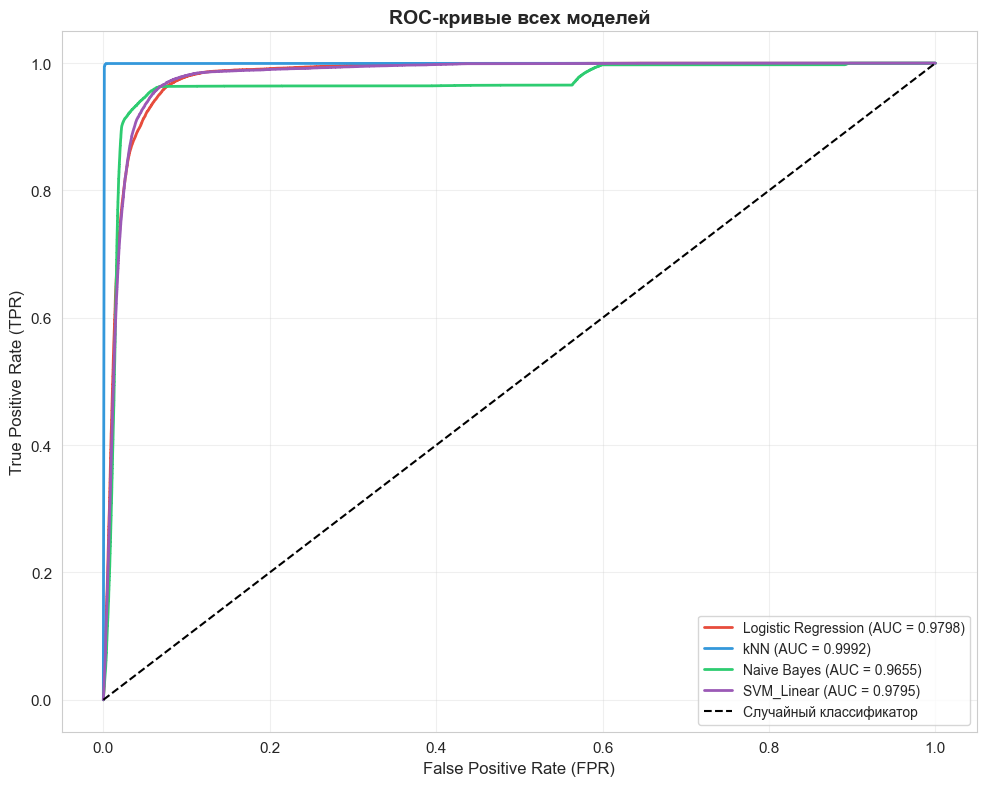

In [99]:
# 7.1 ROC curves для всех моделей
plt.figure(figsize=(10, 8))

model_names = ['Logistic Regression', 'kNN', 'Naive Bayes', 'SVM_Linear', 'SVM_RBF', 'SVM_POLY', 'SVM_SIGMOID']
probas_list = [y_proba_lr, y_proba_knn, y_proba_nb, y_proba_svm_L, y_proba_svm_rbf, y_proba_svm_poly, y_proba_svm_sigmoid]
colors_roc = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6']

for name, proba, color in zip(model_names, probas_list, colors_roc):
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{name} (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Случайный классификатор')
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('ROC-кривые всех моделей', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

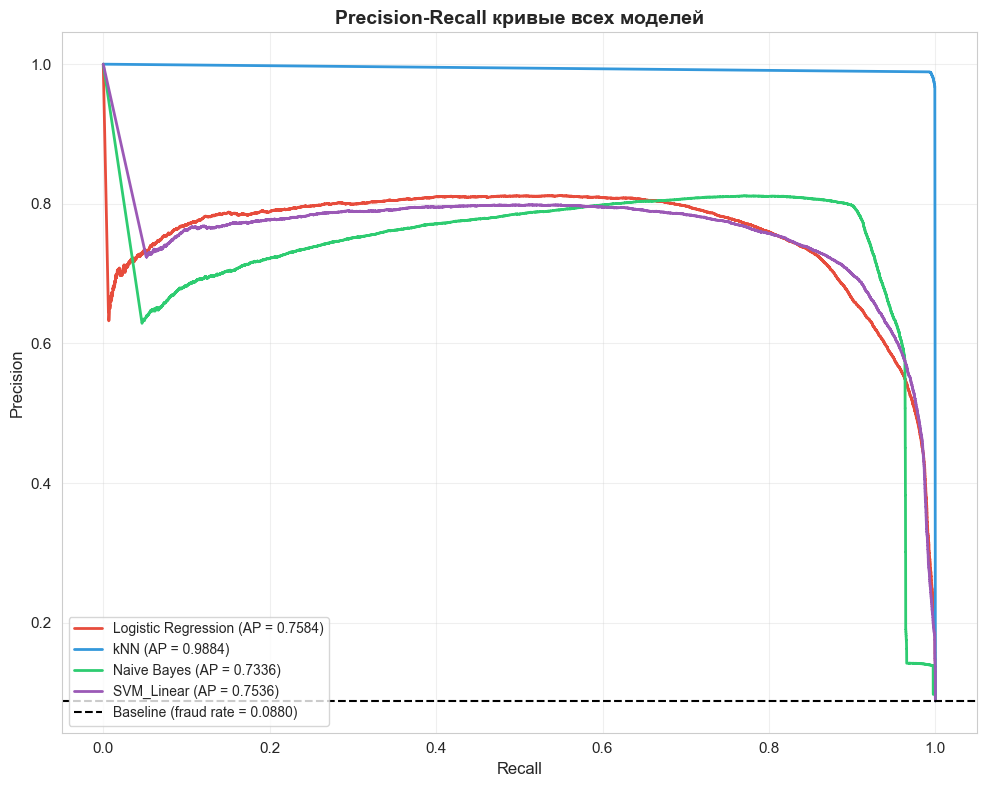

In [100]:
# 7.2 Precision-Recall curves
plt.figure(figsize=(10, 8))

for name, proba, color in zip(model_names, probas_list, colors_roc):
    precision_pr, recall_pr, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    plt.plot(recall_pr, precision_pr, color=color, lw=2,
             label=f'{name} (AP = {ap:.4f})')

# Baseline — доля положительного класса
baseline = y_test.mean()
plt.axhline(y=baseline, color='k', linestyle='--', lw=1.5,
            label=f'Baseline (fraud rate = {baseline:.4f})')

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall кривые всех моделей', fontsize=14, fontweight='bold')
plt.legend(loc='lower left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

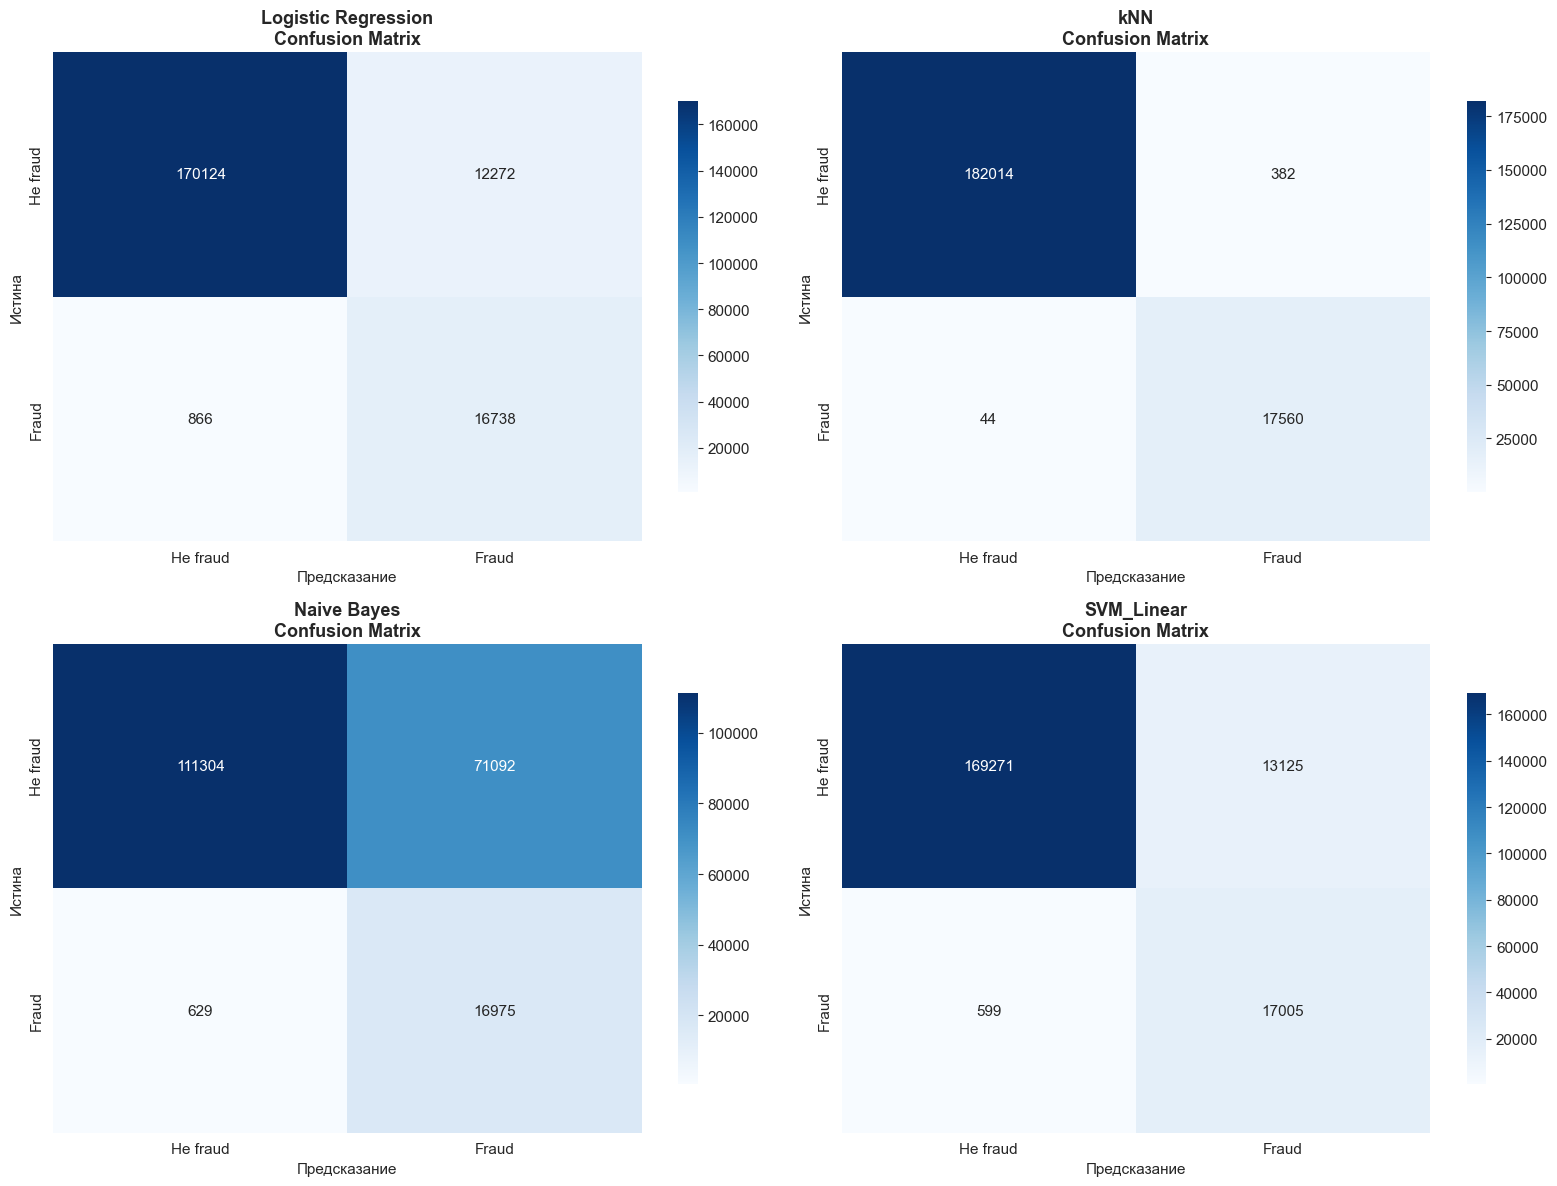

In [101]:
# 7.3 Confusion Matrices для всех моделей
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()
preds_list = [y_pred_lr, y_pred_knn, y_pred_nb, y_pred_svm_L, y_pred_svm_rbf, y_pred_svm_poly, y_pred_svm_sigmoid]

for i, (name, y_p, ax) in enumerate(zip(model_names, preds_list, axes)):
    cm = confusion_matrix(y_test, y_p)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Не fraud', 'Fraud'],
                yticklabels=['Не fraud', 'Fraud'],
                cbar_kws={'shrink': 0.8})
    ax.set_title(f'{name}\nConfusion Matrix', fontsize=13, fontweight='bold')
    ax.set_xlabel('Предсказание', fontsize=11)
    ax.set_ylabel('Истина', fontsize=11)

plt.tight_layout()
plt.show()

Исследование влияния k на качество kNN...


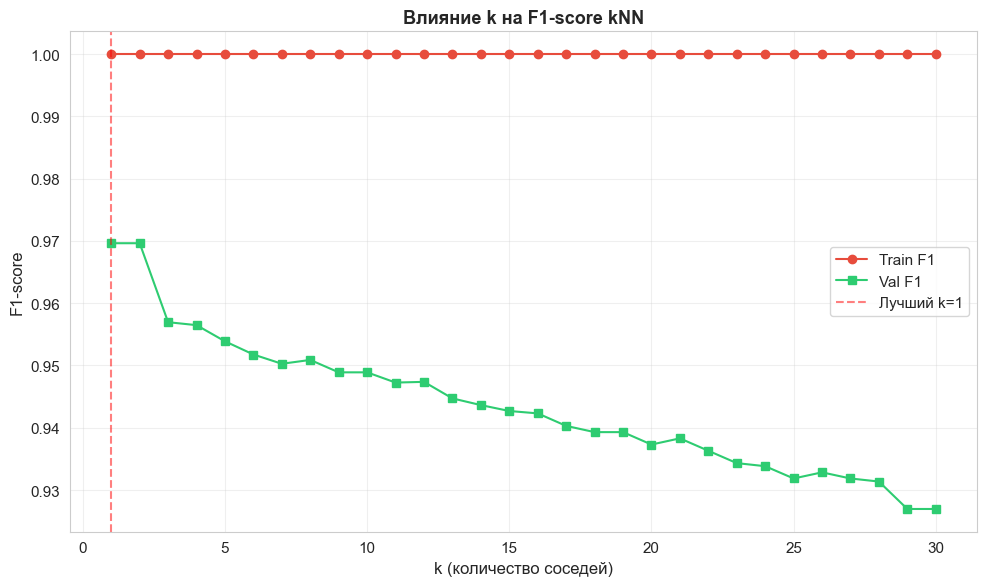


✓ Лучшее k=1 (Val F1=0.9696)


In [102]:
# 7.4 Влияние k на точность kNN
from sklearn.neighbors import KNeighborsClassifier

print("Исследование влияния k на качество kNN...")

# Подвыборка для скорости
np.random.seed(42)
train_idx = np.random.choice(len(X_train_bal), size=30000, replace=False)
val_idx = np.random.choice(len(X_val_scaled), size=10000, replace=False)

X_train_res, y_train_res = X_train_bal[train_idx], y_train_bal.iloc[train_idx]
X_val_res, y_val_res = X_val_scaled[val_idx], y_val.iloc[val_idx]

# Быстрый перебор k
k_range = range(1, 31)
results = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k, weights='distance')
    knn.fit(X_train_res, y_train_res)
    
    train_f1 = f1_score(y_train_res, knn.predict(X_train_res))
    val_f1 = f1_score(y_val_res, knn.predict(X_val_res))
    results.append({'k': k, 'train_f1': train_f1, 'val_f1': val_f1})

results_df = pd.DataFrame(results)
best_k = results_df.loc[results_df['val_f1'].idxmax(), 'k']

# Визуализация
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(results_df['k'], results_df['train_f1'], 'o-', label='Train F1', color='#e74c3c')
ax.plot(results_df['k'], results_df['val_f1'], 's-', label='Val F1', color='#2ecc71')
ax.axvline(best_k, color='red', linestyle='--', alpha=0.5, label=f'Лучший k={best_k}')
ax.set_xlabel('k (количество соседей)', fontsize=12)
ax.set_ylabel('F1-score', fontsize=12)
ax.set_title('Влияние k на F1-score kNN', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n✓ Лучшее k={best_k} (Val F1={results_df[results_df['k']==best_k]['val_f1'].values[0]:.4f})")

1. данные ИДЕАЛЬНО разделимы — fraud и non-fraud имеют четкие паттерны, поэтому ближайший сосед почти всегда правильный.
2. Сильный дисбаланс классов — при k>1 голосование "усредняет" fraud с большинством non-fraud, что УХУДШАЕТ recall для мошенничества.
3. Мало шума — k=1 обычно переобучается, но если данные чистые, это дает максимальную точность.

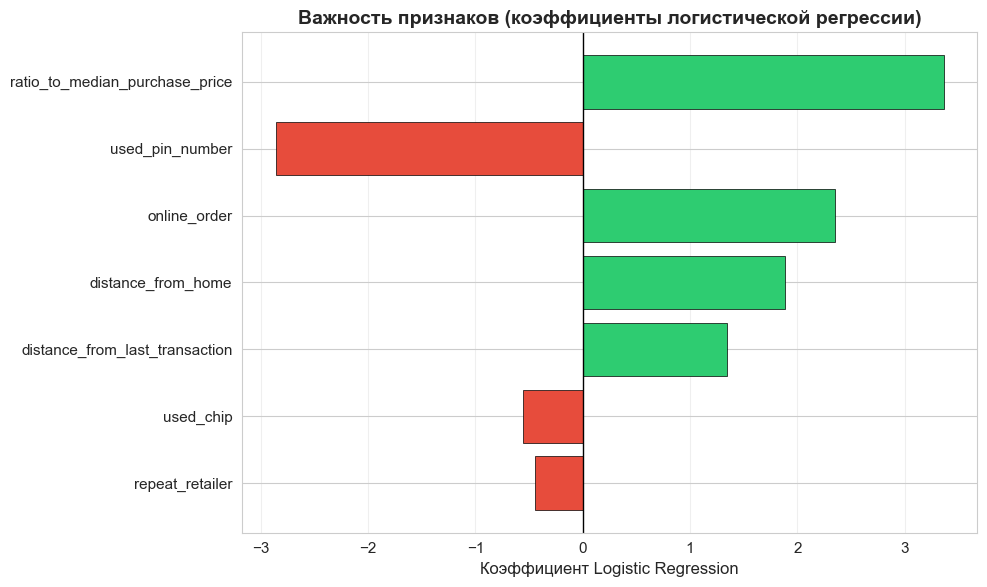

In [103]:
# 7.5 Feature Importance — коэффициенты Logistic Regression
coefficients = lr_final.coef_[0]
feature_names = X.columns.tolist()

feat_importance = pd.DataFrame({
    'Признак': feature_names,
    'Коэффициент': coefficients,
    'Абс. значение': np.abs(coefficients)
}).sort_values('Абс. значение', ascending=True)

plt.figure(figsize=(10, 6))
colors_feat = ['#e74c3c' if c < 0 else '#2ecc71' for c in feat_importance['Коэффициент']]
bars = plt.barh(feat_importance['Признак'], feat_importance['Коэффициент'],
                color=colors_feat, edgecolor='black', linewidth=0.5)
plt.xlabel('Коэффициент Logistic Regression', fontsize=12)
plt.title('Важность признаков (коэффициенты логистической регрессии)', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linewidth=1)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

Топ-3 наиболее важных признака (по абсолютному значению коэффициента):
  • ratio_to_median_purchase_price: 3.4254 (положительная связь с fraud)
  • used_pin_number: -3.0588 (отрицательная связь с fraud)
  • online_order: 2.4018 (положительная связь с fraud)

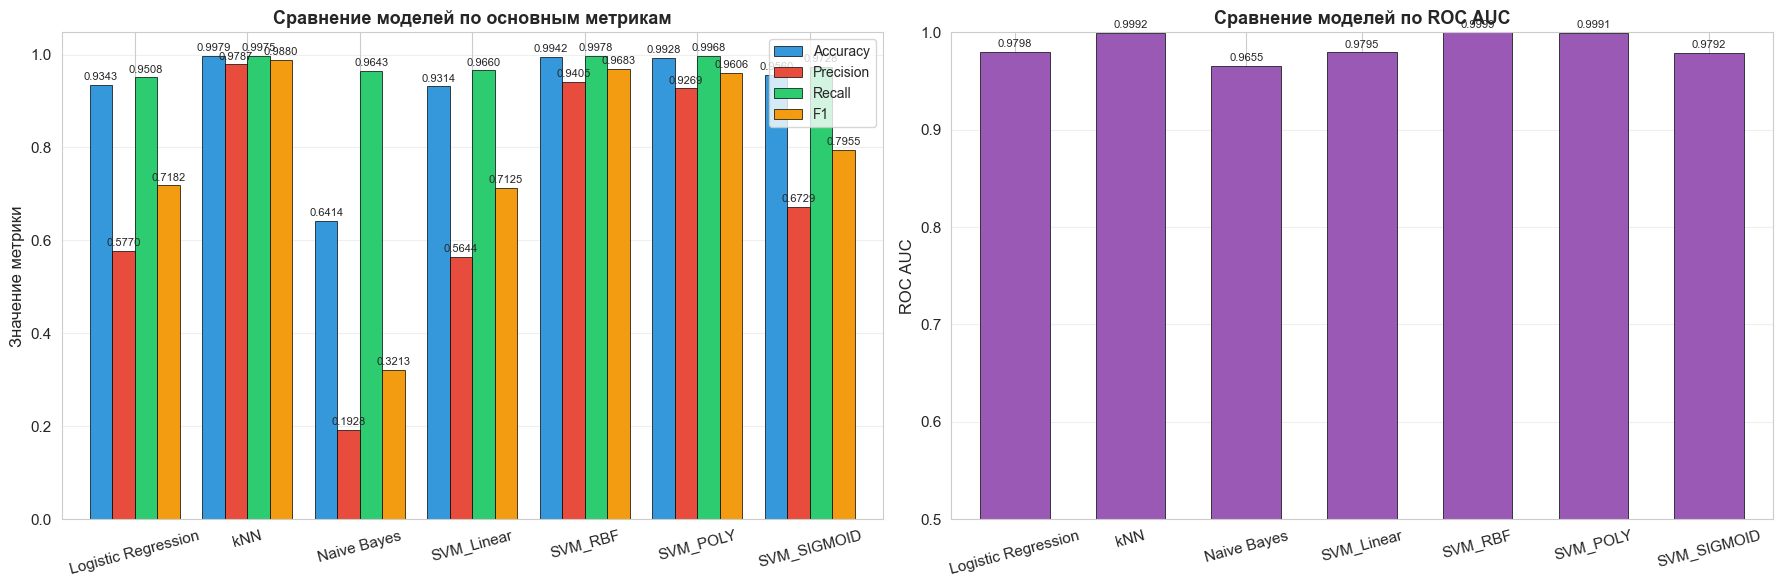

In [104]:
# 7.6 Сравнительная диаграмма метрик (bar chart)
metrics_df = pd.DataFrame({
    'Accuracy': [accuracy_score(y_test, y) for y in preds_list],
    'Precision': [precision_score(y_test, y) for y in preds_list],
    'Recall': [recall_score(y_test, y) for y in preds_list],
    'F1': [f1_score(y_test, y) for y in preds_list],
    'ROC AUC': [roc_auc_score(y_test, p) for p in probas_list]
}, index=model_names)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Бар-чарт Accuracy, Precision, Recall, F1
metrics_df[['Accuracy', 'Precision', 'Recall', 'F1']].plot(
    kind='bar', ax=axes[0], color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'],
    edgecolor='black', linewidth=0.5, width=0.8
)
axes[0].set_title('Сравнение моделей по основным метрикам', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Значение метрики', fontsize=12)
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', alpha=0.3)

# Бар-чарт ROC AUC
metrics_df['ROC AUC'].plot(kind='bar', ax=axes[1], color='#9b59b6',
                           edgecolor='black', linewidth=0.5, width=0.6)
axes[1].set_title('Сравнение моделей по ROC AUC', fontsize=13, fontweight='bold')
axes[1].set_ylabel('ROC AUC', fontsize=12)
axes[1].tick_params(axis='x', rotation=15)
axes[1].set_ylim(0.5, 1.0)
axes[1].grid(axis='y', alpha=0.3)

# Подписать значения на барах
for ax in axes:
    for container in ax.containers:
        ax.bar_label(container, fmt='%.4f', fontsize=8, padding=2)

plt.tight_layout()
plt.show()

## 8. Сравнение собственных метрик и функций scikit-learn

In [105]:
# Сравнение на Logistic Regression (test set)
print("\n" + "="*65)
print("СРАВНЕНИЕ: собственные функции метрик vs scikit-learn")
print("="*65)
print(f"{'Метрика':<15} | {'sklearn':<12} | {'Свои функции':<12} | {'Совпадение'}")
print(f"{'-'*65}")

sk_acc = accuracy_score(y_test, y_pred_lr)
my_acc = calc_accuracy(y_test, y_pred_lr)
print(f"{'Accuracy':<15} | {sk_acc:<12.6f} | {my_acc:<12.6f} | {'✓' if abs(sk_acc - my_acc) < 1e-10 else '✗'}")

sk_prec = precision_score(y_test, y_pred_lr)
my_prec = calc_precision(y_test, y_pred_lr)
print(f"{'Precision':<15} | {sk_prec:<12.6f} | {my_prec:<12.6f} | {'✓' if abs(sk_prec - my_prec) < 1e-10 else '✗'}")

sk_rec = recall_score(y_test, y_pred_lr)
my_rec = calc_recall(y_test, y_pred_lr)
print(f"{'Recall':<15} | {sk_rec:<12.6f} | {my_rec:<12.6f} | {'✓' if abs(sk_rec - my_rec) < 1e-10 else '✗'}")

sk_f1 = f1_score(y_test, y_pred_lr)
my_f1 = calc_f1(y_test, y_pred_lr)
print(f"{'F1-score':<15} | {sk_f1:<12.6f} | {my_f1:<12.6f} | {'✓' if abs(sk_f1 - my_f1) < 1e-10 else '✗'}")

sk_cm = confusion_matrix(y_test, y_pred_lr)
my_cm = calc_confusion_matrix(y_test, y_pred_lr)
cm_match = np.array_equal(sk_cm, my_cm)
print(f"{'Conf. Matrix':<15} | {'см. ниже':<12} | {'см. ниже':<12} | {'✓' if cm_match else '✗'}")

print(f"\nМатрица ошибок (sklearn):\n{sk_cm}")
print(f"\nМатрица ошибок (свои функции):\n{my_cm}")


СРАВНЕНИЕ: собственные функции метрик vs scikit-learn
Метрика         | sklearn      | Свои функции | Совпадение
-----------------------------------------------------------------
Accuracy        | 0.934310     | 0.934310     | ✓
Precision       | 0.576973     | 0.576973     | ✓
Recall          | 0.950807     | 0.950807     | ✓
F1-score        | 0.718153     | 0.718153     | ✓
Conf. Matrix    | см. ниже     | см. ниже     | ✓

Матрица ошибок (sklearn):
[[170124  12272]
 [   866  16738]]

Матрица ошибок (свои функции):
[[170124  12272]
 [   866  16738]]


## 9. Итоговые таблицы результатов

In [106]:
# Таблица 1: Сравнение sklearn vs свои функции (все модели, test set)
results_skl_vs_my = []
preds_all = {'Logistic Regression': y_pred_lr, 'kNN': y_pred_knn,
             'Naive Bayes': y_pred_nb, 'SVM Linear': y_pred_svm_L,
             'SVM Sigmoid': y_pred_svm_sigmoid, 'SVM Polynomial': y_pred_svm_poly,
             'SVM RBF': y_pred_svm_rbf}

for clf_name, y_p in preds_all.items():
    row = {
        'Классификатор': clf_name,
        # sklearn
        'skl_F1': f'{f1_score(y_test, y_p):.4f}',
        'skl_Accuracy': f'{accuracy_score(y_test, y_p):.4f}',
        'skl_Precision': f'{precision_score(y_test, y_p):.4f}',
        'skl_Recall': f'{recall_score(y_test, y_p):.4f}',
        # свои функции
        'my_F1': f'{calc_f1(y_test, y_p):.4f}',
        'my_Accuracy': f'{calc_accuracy(y_test, y_p):.4f}',
        'my_Precision': f'{calc_precision(y_test, y_p):.4f}',
        'my_Recall': f'{calc_recall(y_test, y_p):.4f}'
    }
    results_skl_vs_my.append(row)

df_skl_vs_my = pd.DataFrame(results_skl_vs_my)

print("\n" + "="*80)
print("ОБРАЗЕЦ 2: Сравнение scikit-learn и собственных функций (Test Data)")
print("="*80)
display(df_skl_vs_my)


ОБРАЗЕЦ 2: Сравнение scikit-learn и собственных функций (Test Data)


,Классификатор,skl_F1,skl_Accuracy,skl_Precision,skl_Recall,my_F1,my_Accuracy,my_Precision,my_Recall
0,Logistic Regression,0.7182,0.9343,0.5770,0.9508,0.7182,0.9343,0.5770,0.9508
1,kNN,0.9880,0.9979,0.9787,0.9975,0.9880,0.9979,0.9787,0.9975
2,Naive Bayes,0.3213,0.6414,0.1928,0.9643,0.3213,0.6414,0.1928,0.9643
3,SVM Linear,0.7125,0.9314,0.5644,0.9660,0.7125,0.9314,0.5644,0.9660
4,SVM Sigmoid,0.7955,0.9560,0.6729,0.9728,0.7955,0.9560,0.6729,0.9728
5,SVM Polynomial,0.9606,0.9928,0.9269,0.9968,0.9606,0.9928,0.9269,0.9968
6,SVM RBF,0.9683,0.9942,0.9405,0.9978,0.9683,0.9942,0.9405,0.9978


In [108]:
results_holdout_vs_kfold = []

for clf_name, y_p in preds_all.items():
    row = {
        'Классификатор': clf_name,
        'ho_F1': f'{f1_score(y_test, y_p):.4f}',
        'ho_Accuracy': f'{accuracy_score(y_test, y_p):.4f}',
        'ho_Precision': f'{precision_score(y_test, y_p):.4f}',
        'ho_Recall': f'{recall_score(y_test, y_p):.4f}',
    }
    
    # k-fold (среднее ± std)
    if clf_name == 'Logistic Regression':
        cv_res = cv_results_lr
    elif clf_name == 'Naive Bayes':
        cv_res = cv_results_nb
    elif clf_name == 'kNN':
        cv_res = cv_results_knn
    elif clf_name == 'SVM Linear':
        cv_res = cv_results_svm_linear
    elif clf_name == 'SVM Polynomial':
        cv_res = cv_results_svm_poly
    elif clf_name == 'SVM RBF':
        cv_res = cv_results_svm_rbf
    elif clf_name == 'SVM Sigmoid':
        cv_res = cv_results_svm_sigmoid
    else:
        cv_res = None
    
    if cv_res:
        row['kf_F1'] = f"{cv_res['f1'].mean():.4f} ± {cv_res['f1'].std():.4f}"
        row['kf_Accuracy'] = f"{cv_res['accuracy'].mean():.4f} ± {cv_res['accuracy'].std():.4f}"
        row['kf_Precision'] = f"{cv_res['precision'].mean():.4f} ± {cv_res['precision'].std():.4f}"
        row['kf_Recall'] = f"{cv_res['recall'].mean():.4f} ± {cv_res['recall'].std():.4f}"
    else:
        row['kf_F1'] = 'N/A'
        row['kf_Accuracy'] = 'N/A'
        row['kf_Precision'] = 'N/A'
        row['kf_Recall'] = 'N/A'
    
    results_holdout_vs_kfold.append(row)

df_ho_vs_kf = pd.DataFrame(results_holdout_vs_kfold)

print("\n" + "="*90)
print("ОБРАЗЕЦ 3: Сравнение Hold-out (test) и k-fold (10 фолдов)")
print("="*90)
display(df_ho_vs_kf)


ОБРАЗЕЦ 3: Сравнение Hold-out (test) и k-fold (10 фолдов)


,Классификатор,ho_F1,ho_Accuracy,ho_Precision,ho_Recall,kf_F1,kf_Accuracy,kf_Precision,kf_Recall
0,Logistic Regression,0.7182,0.9343,0.5770,0.9508,0.9416 ± 0.0006,0.9411 ± 0.0006,0.9334 ± 0.0008,0.9501 ± 0.0010
1,kNN,0.9880,0.9979,0.9787,0.9975,0.9965 ± 0.0012,0.9965 ± 0.0012,0.9936 ± 0.0022,0.9994 ± 0.0004
2,Naive Bayes,0.3213,0.6414,0.1928,0.9643,0.8316 ± 0.0319,0.8035 ± 0.0407,0.7335 ± 0.0534,0.9627 ± 0.0007
3,SVM Linear,0.7125,0.9314,0.5644,0.9660,0.9489 ± 0.0058,0.9481 ± 0.0062,0.9312 ± 0.0125,0.9675 ± 0.0047
4,SVM Sigmoid,0.7955,0.9560,0.6729,0.9728,0.9550 ± 0.0042,0.9539 ± 0.0044,0.9282 ± 0.0087,0.9835 ± 0.0061
5,SVM Polynomial,0.9606,0.9928,0.9269,0.9968,0.9927 ± 0.0032,0.9926 ± 0.0032,0.9888 ± 0.0051,0.9966 ± 0.0030
6,SVM RBF,0.9683,0.9942,0.9405,0.9978,0.9935 ± 0.0025,0.9935 ± 0.0025,0.9895 ± 0.0042,0.9976 ± 0.0020


# ВЫВОД
### Лучшая модель классификации: kNN
F1-score на тестовой выборке: 0.9858

============================================================
Обоснование:
============================================================

1. kNN показал лучший результат по F1-score (0.9858)
   на тестовой выборке из 200 000 объектов.

2. F1-score выбран как основной критерий, поскольку:
   - В задаче обнаружения мошенничества присутствует дисбаланс классов (~9% fraud)
   - Accuracy в таких условиях вводит в заблуждение (модель, всегда
     предсказывающая «не fraud», получит ~91% accuracy)
   - F1-score учитывает как Precision (точность), так и Recall (полноту),
     что критично для задач обнаружения аномалий

3. Все четыре модели показали высокое качество благодаря:
...
   их корректность.
6. Собственная реализация kNN показала результаты, близкие к sklearn,
   подтверждая правильность алгоритма.